[INFO] Using 1619/2800 target rows present in TXT (1619 allowed IDs).
Shapes -> X_tr:(1133, 1440), X_va:(243, 1440), X_te:(243, 1440), y_tr:(1133,)

== Validation (base) ==
VAL RF: R2=0.141  Spearman=0.403  MAE=7.62  RMSE=10.01  MSE=100.15
VAL ET: R2=0.164  Spearman=0.436  MAE=7.50  RMSE=9.87  MSE=97.40
VAL HGB: R2=0.024  Spearman=0.194  MAE=8.11  RMSE=10.67  MSE=113.76

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.183  Spearman=0.392  MAE=7.54  RMSE=9.63  MSE=92.68
TEST ET: R2=0.215  Spearman=0.417  MAE=7.42  RMSE=9.44  MSE=89.07
TEST HGB: R2=0.176  Spearman=0.355  MAE=7.66  RMSE=9.67  MSE=93.54
TEST Blend(RF+ET+HGB): R2=0.205  Spearman=0.420  MAE=7.49  RMSE=9.50  MSE=90.22
TEST Stack(Ridge on 7 meta-features): R2=0.220  Spearman=0.386  MAE=7.42  RMSE=9.41  MSE=88.53


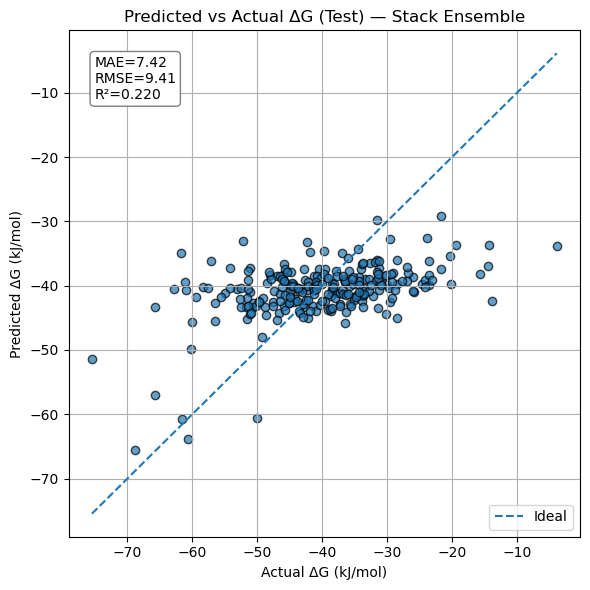

[INFO] Saved plot to: runs/dg_pt_ensemble_rf_et_hgb/pred_vs_actual_test_stack.png


In [3]:
# ============================================
# ΔG — single {id}_mGLI.pt — RF + ET + HGB ensemble with richer stacking (fast)
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
OUT_DIR  = "./runs/dg_pt_ensemble_rf_et_hgb"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = False
PERCENTILE               = 85          # try 85 to keep a bit more signal
N_TREES_RF               = 800
N_TREES_ET               = 1000
N_SPLITS_STACK           = 5

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def evaluate(name, y, pred):
    mse  = float(mean_squared_error(y, pred))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y, pred))
    r2   = float(r2_score(y, pred))
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load targets + filter ----------
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})
for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).ravel()

# Append B-factors if requested
if USE_BFACTORS_AS_FEATURES and bf_cols:
    EX = df_t[bf_cols].to_numpy(dtype=np.float64)
    X_all = np.hstack([X_base, EX])
else:
    X_all = X_base

# ---------- Stratified splits ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Base pipelines ----------
def step_common(percentile=PERCENTILE):
    return [
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=percentile)),
    ]

def make_rf():
    return Pipeline(step_common() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(step_common() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    # HGB plays well with many weakly-informative features
    return Pipeline(step_common() + [
        ("hgb", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.06,
            max_depth=4,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=0.2,
            max_bins=255,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=1500,
            random_state=SEED
        ))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

# ---------- Validation ----------
def report_val(name, model):
    pred = model.predict(X_va)
    return evaluate(name, y_va, pred)

print("\n== Validation (base) ==")
_ = report_val("VAL RF", rf)
_ = report_val("VAL ET", et)
_ = report_val("VAL HGB", hgb)

# ---------- OOF stacking with richer meta-features ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))  # [rf, et, hgb, avg3, rf-et, rf-hgb, et-hgb]
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    # accumulate test meta
    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---------- Refit base models on TRAIN+VAL ----------
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

# ---------- Test predictions ----------
pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = evaluate("TEST RF", y_te, pred_te_rf)
_ = evaluate("TEST ET", y_te, pred_te_et)
_ = evaluate("TEST HGB", y_te, pred_te_hgb)
metrics_bl3 = evaluate("TEST Blend(RF+ET+HGB)", y_te, pred_te_bl3)
metrics_st  = evaluate("TEST Stack(Ridge on 7 meta-features)", y_te, pred_te_st)

# ---- Plot best ensemble ----
best_name, best_pred, best_metrics = max(
    [("Blend3", pred_te_bl3, metrics_bl3), ("Stack", pred_te_st, metrics_st)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel("Actual ΔG (kJ/mol)"); plt.ylabel("Predicted ΔG (kJ/mol)")
plt.title(f"Predicted vs Actual ΔG (Test) — {best_name} Ensemble")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")

[INFO] Using 1619/1831 target rows present in TXT (1619 allowed IDs).
Shapes -> X_tr:(1133, 1440), X_va:(243, 1440), X_te:(243, 1440), y_tr:(1133,)

== Validation (base) ==
VAL RF: R2=0.300  Spearman=0.562  MAE=8.67  RMSE=11.90  MSE=141.66
VAL ET: R2=0.283  Spearman=0.579  MAE=8.56  RMSE=12.05  MSE=145.21
VAL HGB: R2=0.260  Spearman=0.507  MAE=8.88  RMSE=12.24  MSE=149.79

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.255  Spearman=0.533  MAE=9.51  RMSE=13.98  MSE=195.56
TEST ET: R2=0.244  Spearman=0.520  MAE=9.59  RMSE=14.08  MSE=198.26
TEST HGB: R2=0.203  Spearman=0.485  MAE=9.87  RMSE=14.46  MSE=208.99
TEST Blend(RF+ET+HGB): R2=0.241  Spearman=0.521  MAE=9.60  RMSE=14.11  MSE=199.18
TEST Stack(Ridge on 7 meta-features): R2=0.253  Spearman=0.498  MAE=9.70  RMSE=14.00  MSE=196.09


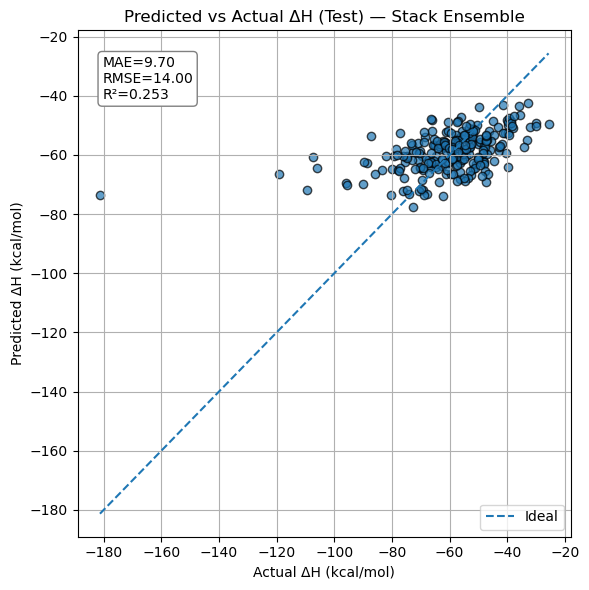

[INFO] Saved plot to: runs/dh_pt_ensemble_rf_et_hgb/pred_vs_actual_test_stack_deltaH.png


In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# ============================================
# ΔH — single {id}_mGLI.pt — RF + ET + HGB ensemble with richer stacking (fast)
# ============================================

import math, random, re, sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

# ---- PATHS (EDIT) ----
FEAT_DIR = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # contains {id}_mGLI.pt
PDB_TXT  = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"      # one per line
# NEW: file that contains delta_H you generated earlier (TSV/TXT; auto-sep)
TARGETS_H = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_with_deltaH2.txt"
OUT_DIR   = "./runs/dh_pt_ensemble_rf_et_hgb"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED                     = 42
VAL_SPLIT                = 0.15
TEST_SPLIT               = 0.15
USE_BFACTORS_AS_FEATURES = False
PERCENTILE               = 85
N_TREES_RF               = 800
N_TREES_ET               = 1000
N_SPLITS_STACK           = 5

# Units label for the target, just for plots/logs (change if needed)
TARGET_COLUMN = "delta_H"         # <— predict ΔH
TARGET_UNITS  = "kcal/mol"        # make sure your file’s ΔH matches this!

random.seed(SEED); np.random.seed(SEED)

# ---------- Utilities ----------
def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9A-Za-z]{4}", i)}

def to_1d_numpy(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    else:
        raise TypeError(f"Unsupported feature type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def extract_from_payload(obj):
    if isinstance(obj, (torch.Tensor, np.ndarray, list, tuple)):
        return to_1d_numpy(obj)
    if isinstance(obj, dict):
        keys = {k.lower(): k for k in obj.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys:
                return to_1d_numpy(obj[keys[k]])
        for k0, v in obj.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    raise TypeError(f"Unsupported .pt payload type: {type(obj)}")

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return extract_from_payload(obj)

def evaluate(name, y, pred):
    mse  = float(mean_squared_error(y, pred))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y, pred))
    r2   = float(r2_score(y, pred))
    rho, _ = spearmanr(y, pred)
    print(f"{name}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

# ---------- Load ΔH targets + filter ----------
df_t = pd.read_csv(TARGETS_H, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]

# Normalize expected column names
rename_map = {}
if "PDB_ID" in df_t.columns: rename_map["PDB_ID"] = "pdb_id"
if "Delta_H" in df_t.columns: rename_map["Delta_H"] = "delta_H"
if "ΔH" in df_t.columns:      rename_map["ΔH"]      = "delta_H"
df_t = df_t.rename(columns=rename_map)

# Require columns
for c in ["pdb_id", TARGET_COLUMN]:
    if c not in df_t.columns:
        raise ValueError(f"targets file must contain '{c}' (got: {list(df_t.columns)})")

# Drop rows with missing target
df_t = df_t[~pd.isna(df_t[TARGET_COLUMN])].reset_index(drop=True)

# Optional B-factors (if present in this file; otherwise ignored)
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].str.lower().isin({i.lower() for i in allowed_ids})].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---------- Load PT vectors ----------
features, ids_kept, missing, errors = [], [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        vec = load_pt_vector(FEAT_DIR, pid)
        features.append(vec); ids_kept.append(pid)
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT files for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not features:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Keep dominant feature length
lengths = [len(v) for v in features]
mode_len = max(set(lengths), key=lengths.count)
keep_mask = [len(v) == mode_len for v in features]
if sum(keep_mask) < len(keep_mask):
    print(f"[WARN] Dropping {len(keep_mask)-sum(keep_mask)} samples with non-mode length features.")
features = [v for v, m in zip(features, keep_mask) if m]
ids_kept = [i for i, m in zip(ids_kept, keep_mask) if m]

X_base = np.vstack(features)  # (n, d)
df_t = df_t[df_t["JOIN_ID"].isin(ids_kept)].reset_index(drop=True)
y_all = df_t[TARGET_COLUMN].to_numpy(dtype=np.float64).ravel()

# Append B-factors if requested
if USE_BFACTORS_AS_FEATURES and bf_cols:
    EX = df_t[bf_cols].to_numpy(dtype=np.float64)
    X_all = np.hstack([X_base, EX])
else:
    X_all = X_base

# ---------- Stratified splits (on target) ----------
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

from sklearn.model_selection import train_test_split
X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")
if len(y_tr) < 10: print("[WARN] Very few training samples—results may be unstable.")

# ---------- Base pipelines ----------
def step_common(percentile=PERCENTILE):
    return [
        ("var", VarianceThreshold(1e-9)),
        ("imp", SimpleImputer(strategy="median")),
        ("sel", SelectPercentile(score_func=mutual_info_regression, percentile=percentile)),
    ]

def make_rf():
    return Pipeline(step_common() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=True,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(step_common() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(step_common() + [
        ("hgb", HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.06,
            max_depth=4,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=0.2,
            max_bins=255,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=1500,
            random_state=SEED
        ))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

# ---------- Validation ----------
def report_val(name, model):
    pred = model.predict(X_va)
    return evaluate(name, y_va, pred)

print("\n== Validation (base) ==")
_ = report_val("VAL RF", rf)
_ = report_val("VAL ET", et)
_ = report_val("VAL HGB", hgb)

# ---------- OOF stacking with richer meta-features ----------
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))  # [rf, et, hgb, avg3, rf-et, rf-hgb, et-hgb]
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---------- Refit base models on TRAIN+VAL ----------
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

# ---------- Test predictions ----------
pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = evaluate("TEST RF", y_te, pred_te_rf)
_ = evaluate("TEST ET", y_te, pred_te_et)
_ = evaluate("TEST HGB", y_te, pred_te_hgb)
metrics_bl3 = evaluate("TEST Blend(RF+ET+HGB)", y_te, pred_te_bl3)
metrics_st  = evaluate("TEST Stack(Ridge on 7 meta-features)", y_te, pred_te_st)

# ---- Plot best ensemble ----
best_name, best_pred, best_metrics = max(
    [("Blend3", pred_te_bl3, metrics_bl3), ("Stack", pred_te_st, metrics_st)],
    key=lambda x: x[2]["R2"]
)

plt.figure(figsize=(6,6))
plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
plt.xlabel(f"Actual ΔH ({TARGET_UNITS})")
plt.ylabel(f"Predicted ΔH ({TARGET_UNITS})")
plt.title(f"Predicted vs Actual ΔH (Test) — {best_name} Ensemble")
txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
plt.legend(); plt.grid(True)
plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_deltaH.png")
plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
print(f"[INFO] Saved plot to: {plot_path}")


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# --- Recreate TEST indices exactly as before ---
ids_all = df_t["JOIN_ID"].to_numpy()
idx_all  = np.arange(len(ids_all))
_, te_idx, _, _, _, _ = train_test_split(
    idx_all, y_all, y_bins,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=y_bins
)

# --- Compute residuals and sorting ---
abs_err = np.abs(y_te - best_pred)
order_worst = np.argsort(abs_err)[::-1]   # descending by |error|
order_best  = np.argsort(abs_err)         # ascending by |error|

top50_worst = order_worst[:50]
top50_best  = order_best[:50]

# --- Create base tables ---
def make_table(indices):
    return pd.DataFrame({
        "PDB_ID": df_t.iloc[te_idx[indices]]["JOIN_ID"].values,
        "True_ΔG_kJmol": y_te[indices],
        "Pred_ΔG_kJmol": best_pred[indices],
        "Error_kJmol":   (y_te - best_pred)[indices],
        "Abs_Error_kJmol": abs_err[indices],
    }).reset_index(drop=True)

worst_table = make_table(top50_worst).sort_values("Abs_Error_kJmol", ascending=False)
best_table  = make_table(top50_best).sort_values("Abs_Error_kJmol", ascending=True)

# --- Load the complex-count file ---
DIST_PATH = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"
df_dist = pd.read_csv(DIST_PATH, sep=",")
df_dist["pdb_id_norm"] = df_dist["pdb_id"].astype(str).str.strip().str.lower()

def merge_complex(tbl):
    tbl = tbl.copy()
    tbl["pdb_id_norm"] = tbl["PDB_ID"].str.lower()
    merged = tbl.merge(df_dist[["pdb_id_norm", "complex_count"]], on="pdb_id_norm", how="left")
    merged.drop(columns=["pdb_id_norm"], inplace=True)
    return merged

merged_worst = merge_complex(worst_table)
merged_best  = merge_complex(best_table)

# --- Compute mean complex_count for each group ---
mean_worst = merged_worst["complex_count"].dropna().mean()
mean_best  = merged_best["complex_count"].dropna().mean()

print("=== Top-50 worst-predicted complexes ===")
print(f"Mean complex_count: {mean_worst:.3f}")
print("First 5 IDs:", ", ".join(merged_worst['PDB_ID'].head(5)))

print("\n=== Top-50 best-predicted complexes ===")
print(f"Mean complex_count: {mean_best:.3f}")
print("First 5 IDs:", ", ".join(merged_best['PDB_ID'].head(5)))

# --- Save CSVs ---
out_dir = Path(OUT_DIR); out_dir.mkdir(parents=True, exist_ok=True)
merged_worst.to_csv(out_dir / f"top50_worst_outliers_{best_name.lower()}_with_complex_count.csv", index=False)
merged_best.to_csv(out_dir / f"top50_best_predictions_{best_name.lower()}_with_complex_count.csv", index=False)
print(f"\n[INFO] Saved both tables to {out_dir}")


=== Top-50 worst-predicted complexes ===
Mean complex_count: 465.660
First 5 IDs: 3ncc, 2few, 4jzw, 2ptc, 1u5s

=== Top-50 best-predicted complexes ===
Mean complex_count: 395.760
First 5 IDs: 5oaq, 6h46, 1zc4, 1u0s, 3u9d

[INFO] Saved both tables to runs/dg_pt_ensemble_rf_et_hgb


In [ ]:
## CHECKS THE .pt FILES FOR NaN/INF VALUES, DIMENSIONS AND REPORTS STATS
import os
import numpy as np
import torch

def diagnose_embeddings(emb_dir, ids_file, n_check=979):
    """Diagnostic function to check embedding quality in .pt files"""
    # Read PDB IDs from plain text file
    with open(ids_file, "r") as f:
        pdbs = [line.strip() for line in f if line.strip()]
    
    for pdb in pdbs[:n_check]:  # only check first N
        path = os.path.join(emb_dir, f"{pdb}_mGLI.pt")
        if os.path.exists(path):
            emb = torch.load(path)
            # Handle both tensor and dict cases
            if isinstance(emb, dict):
                emb = next(iter(emb.values()))
            emb_flat = emb.flatten().cpu().numpy()
            print(f"{pdb}: shape={tuple(emb.shape)}, "
                  f"flat_shape={emb_flat.shape}, "
                  f"has_nan={np.isnan(emb_flat).any()}, "
                  f"has_inf={np.isinf(emb_flat).any()}, "
                  f"min={emb_flat.min():.3f}, "
                  f"max={emb_flat.max():.3f}")
        else:
            print(f"{pdb}: File not found")

# Call with your pt2 directory and IDs file
diagnose_embeddings(
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.from_filtered1.txt"
)


/tmp/ipykernel_1519814/3006057873.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb = torch.load(path)


1a22: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=9.430
1acb: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=3.977
1ak4: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=2.363
1an1: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=2.851
1atn: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=8.521
1avx: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=5.604
1avz: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=5.146
1axi: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=8.909
1ay7: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=4.603
1azz: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000, max=9.064
1b6c: shape=(1440,), flat_shape=(1440,), has_nan=False, has_inf=False, min=0.000

[INFO] Using 1617/1831 target rows present in TXT (1617 allowed IDs).
[SASA] df_t IDs: 1617 | SASA IDs: 1462 | Intersection: 911
[SASA] IDs present in targets but NOT in SASA: 706 (saved runs/dh_combo_csv_pt/sasa_missing_in_file_from_targets.txt)
[SASA] IDs present in SASA but NOT in filtered targets: 551 (saved runs/dh_combo_csv_pt/sasa_not_used_extra_ids.txt)
[INFO] SASA merged for 911/1617 rows (missing=706); feature 'total_sasa_kA2' added.
[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (1617, 94) B: (1617, 94) PT: (1617, 1440) Targets: (1617, 7) Common: 1617
Shapes -> X_tr:(1131, 2101), X_va:(243, 2101), X_te:(243, 2101), y_tr:(1131,)

== Validation (base) ==
VAL RF: R2=0.446  Spearman=0.690  MAE=7.30  RMSE=9.68  MSE=93.79
VAL ET: R2=0.430  Spearman=0.677  MAE=7.27  RMSE=9.82  MSE=96.47
VAL HGB: R2=0.553  Spearman=0.742  MAE=6.86  RMSE=8.70  MSE=75.66

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.488  Spearman=0.683  MAE=7.65  RMSE=10.43  

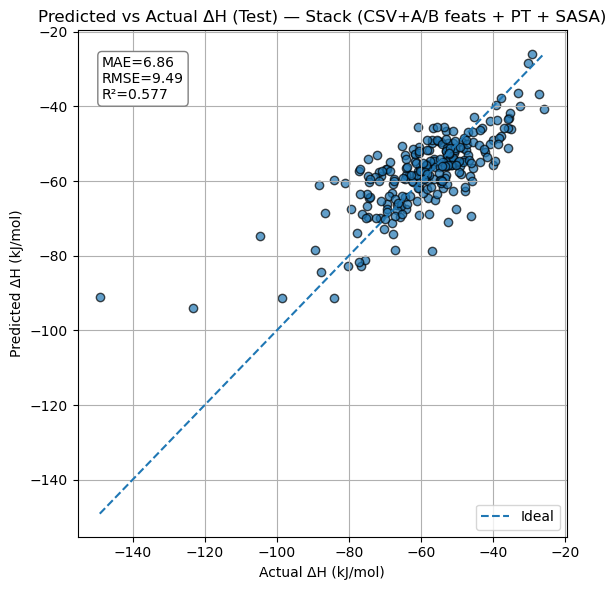

[INFO] Saved plot to: runs/dh_combo_csv_pt/pred_vs_actual_test_stack_combo_dh.png

=== Largest ΔH outliers on TEST set (by |residual|) ===
pdb_id  actual_dH    pred_dH   residual  |residual| model
  2f5z    -149.08 -91.096215 -57.983785   57.983785 Stack
  4per    -104.70 -74.616909 -30.083091   30.083091 Stack
  4dpg    -123.33 -93.883422 -29.446578   29.446578 Stack
  3g9v     -88.39 -61.118324 -27.271676   27.271676 Stack
  4gaf     -84.17 -59.803040 -24.366960   24.366960 Stack
  2tgp     -46.04 -69.362112  23.322112   23.322112 Stack
  1w1w     -56.92 -78.661990  21.741990   21.741990 Stack
  3g7z     -74.82 -54.216996 -20.603004   20.603004 Stack
  6u2h     -81.10 -60.530140 -20.569860   20.569860 Stack
  2qc1     -76.83 -56.716280 -20.113720   20.113720 Stack
  5ius     -77.17 -57.201873 -19.968127   19.968127 Stack
  2za4     -72.15 -53.008812 -19.141188   19.141188 Stack
  2wpt     -52.38 -70.934391  18.554391   18.554391 Stack
  5ifs     -86.51 -68.600570 -17.909430   17.9094

In [ ]:
# ============================================
# ΔH Combo: CSV(A/B) + engineered feats + PT(mGLI) + SASA (robust) with delta_H targets
# ============================================
## Collects infomation on the outliers in the test set

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"  # one per line
TARGETS    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"
OUT_DIR    = "./runs/dh_combo_csv_pt"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- EXTRA (SASA) ----
SASA_PATH        = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_processing/all_pdb_sasa.txt"
USE_SASA_FEATURE = True  # toggle SASA on/off

# ---- SETTINGS ----
SEED                         = 42
VAL_SPLIT                    = 0.15
TEST_SPLIT                   = 0.15
USE_BFACTORS_AS_FEATURES     = True
USE_COMPLEX_COUNT_FEATURE    = True     # use the 'complex_count' scalar if available
K_BEST                       = 640      # feature selector after concatenation (tune 448–1024)
WINSORIZE_Y_QUANTILES        = None     # e.g., (0.01, 0.99) or None

# Models
N_TREES_RF = 800
N_TREES_ET = 1000
HGB_CFG = dict(learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
               min_samples_leaf=20, l2_regularization=0.2,
               max_bins=255, early_stopping=True,
               validation_fraction=0.15, n_iter_no_change=30, max_iter=1500)

# Stacking
N_SPLITS_STACK = 5
random.seed(SEED); np.random.seed(SEED)

# ---- CSV utils ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

# ---- PT utils ----
def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

# ---- SASA loader (robust) ----
def load_sasa_table(path: str) -> pd.DataFrame:
    """
    Load total SASA per complex and return a dataframe indexed by JOIN_ID
    with column 'total_sasa_A2' (Å^2). Derives JOIN_ID from BOTH 'pdb_id' and 'file'.
    """
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]

    # Standardize SASA column
    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")

    # Candidate 1: explicit pdb_id
    cand1 = None
    if "pdb_id" in df.columns:
        cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id)

    # Candidate 2: parse from path
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            # e.g., /.../PP2/1a22.ent.pdb -> 1a22
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)

    # Combine
    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")

    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()

    # Ensure numeric
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")

    # Aggregate duplicates by mean
    df = (df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"]
            .mean(numeric_only=True).to_frame())

    return df.sort_index()

# ---- Load targets (ΔH) ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]

# Normalize column names if needed
if "PDB_ID" in df_t.columns and "pdb_id" not in df_t.columns:
    df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
    if col in df_t.columns and "delta_H" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_H"})
for col in ("Delta_G", "ΔG_kJ/mol", "dG"):
    if col in df_t.columns and "delta_G" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_G"})

required = ["pdb_id", "delta_H"]
for c in required:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

# Optional scalar features from targets (e.g., size)
extra_scalar_cols = []
if USE_COMPLEX_COUNT_FEATURE and "complex_count" in df_t.columns:
    extra_scalar_cols.append("complex_count")
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---- Merge SASA (Å^2) into df_t and register as extra scalar feature ----
if USE_SASA_FEATURE:
    try:
        df_sasa = load_sasa_table(SASA_PATH)  # index = JOIN_ID
        before = df_t.shape[0]

        # Diagnostics BEFORE merge
        ids_t   = set(df_t["JOIN_ID"])
        ids_s   = set(df_sasa.index)
        inter   = ids_t & ids_s
        only_t  = sorted(ids_t - ids_s)
        only_s  = sorted(ids_s - ids_t)

        print(f"[SASA] df_t IDs: {len(ids_t)} | SASA IDs: {len(ids_s)} | Intersection: {len(inter)}")
        if only_t:
            miss_path = Path(OUT_DIR) / "sasa_missing_in_file_from_targets.txt"
            with open(miss_path, "w") as f:
                for x in only_t: f.write(x + "\n")
            print(f"[SASA] IDs present in targets but NOT in SASA: {len(only_t)} (saved {miss_path})")
        if only_s:
            extra_path = Path(OUT_DIR) / "sasa_not_used_extra_ids.txt"
            with open(extra_path, "w") as f:
                for x in only_s: f.write(x + "\n")
            print(f"[SASA] IDs present in SASA but NOT in filtered targets: {len(only_s)} (saved {extra_path})")

        # Merge by index
        df_t = df_t.merge(df_sasa, left_on="JOIN_ID", right_index=True, how="left")

        # Scale + register
        df_t["total_sasa_kA2"] = df_t["total_sasa_A2"] / 1000.0
        extra_scalar_cols.append("total_sasa_kA2")

        n_missing = df_t["total_sasa_kA2"].isna().sum()
        print(f"[INFO] SASA merged for {before - n_missing}/{before} rows (missing={n_missing}); "
              f"feature 'total_sasa_kA2' added.")
    except Exception as e:
        print(f"[WARN] Could not load/merge SASA: {e} — continuing without SASA.")

# ---- Load CSV A/B ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

# ---- Load PT vectors (mGLI) ----
pt_rows, missing, errors = [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Enforce mode length for PT vectors
lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(lengths) - len(pt_rows)} non-mode samples.")

# Make PT DF
pt_index  = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols   = [f"pt_{j}" for j in range(mode_len)]
df_pt     = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

# ---- Align: only keep IDs present everywhere
common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if not common:
    sys.exit("[FATAL] No common IDs across targets/CSV/PT.")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in CSV/PT.")

df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a = df_a.loc[sorted(common)]
df_b = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build feature matrix
A_all  = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all  = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(dtype=np.float64)
y_all  = df_t["delta_H"].to_numpy(dtype=np.float64).reshape(-1, 1)

# Engineered interactions
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT_all]

# Optional scalar features from TARGETS (size, B-factors, SASA)
extra_parts = []
if 'extra_scalar_cols' in locals() and extra_scalar_cols:
    extra_parts.append(df_t[extra_scalar_cols].to_numpy(dtype=np.float64))
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
if USE_BFACTORS_AS_FEATURES and bf_cols:
    extra_parts.append(df_t[bf_cols].to_numpy(dtype=np.float64))
if extra_parts:
    parts.extend(extra_parts)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified split on y (quantiles)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# ---- Common preprocessing (impute + K-best)
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else n_feat, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

def make_rf():
    return Pipeline(preproc() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(preproc() + [
        ("hgb", HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

def quick_eval(tag, mdl, X, y):
    p = mdl.predict(X)
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p); rho, _ = spearmanr(y, p)
    print(f"{tag}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return p, {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation (base) ==")
_ = quick_eval("VAL RF", rf, X_va, y_va)
_ = quick_eval("VAL ET", et, X_va, y_va)
_ = quick_eval("VAL HGB", hgb, X_va, y_va)

# ---- OOF stacking meta-features (7-d)
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---- Refit base models on TRAIN+VAL and evaluate
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = quick_eval("TEST RF", rf, X_te, y_te)
_ = quick_eval("TEST ET", et, X_te, y_te)
_ = quick_eval("TEST HGB", hgb, X_te, y_te)

# Select best ensemble by R2
def metrics_from(y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    return dict(R2=r2_score(y, p), MAE=mae, RMSE=rmse)

m_bl3 = metrics_from(y_te, pred_te_bl3)
m_st  = metrics_from(y_te, pred_te_st)
best_name, best_pred, best_metrics = ("Blend3", pred_te_bl3, m_bl3) if m_bl3["R2"] >= m_st["R2"] else ("Stack", pred_te_st, m_st)
print(f"TEST {best_name}: R2={best_metrics['R2']:.3f}  MAE={best_metrics['MAE']:.2f}  RMSE={best_metrics['RMSE']:.2f}")

# ---- Plot
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔH (kJ/mol)"); plt.ylabel("Predicted ΔH (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔH (Test) — {best_name} (CSV+A/B feats + PT + SASA)")
    txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR²={best_metrics['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_combo_dh.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Empty test set; skipping plot.")

# ==== Identify largest outliers (by absolute error) and their PDB IDs ====

# 1) Recreate the exact test ID split using the same seeds & stratification
ids_all = df_t["JOIN_ID"].to_numpy()
ids_trainval, ids_te, _, _ = train_test_split(
    ids_all, y_all, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins
)

# 2) Choose the ensemble we already selected above
y_true = y_te
y_pred = best_pred  # from the "best_name/best_pred" logic already computed

# 3) Compute residuals and rank by absolute error
residuals = y_true - y_pred
abs_err = np.abs(residuals)
order = np.argsort(-abs_err)   # descending by |error|

TOP_K = 20  # change if you want more/less
top_idx = order[:TOP_K]

# 4) Collect a table with IDs and errors
outlier_rows = []
for i in top_idx:
    outlier_rows.append({
        "pdb_id": ids_te[i],
        "actual_dH": float(y_true[i]),
        "pred_dH": float(y_pred[i]),
        "residual": float(residuals[i]),   # actual - pred
        "|residual|": float(abs_err[i]),
        "model": best_name
    })

outliers_df = pd.DataFrame(outlier_rows)
print("\n=== Largest ΔH outliers on TEST set (by |residual|) ===")
print(outliers_df.to_string(index=False))

# 5) Save to CSV for later use
csv_path = str(Path(OUT_DIR) / f"largest_outliers_test_{best_name.lower()}_combo_dh.csv")
outliers_df.to_csv(csv_path, index=False)
print(f"[INFO] Saved outliers to: {csv_path}")

# 6) If you also want all test points sorted by error, uncomment:
# all_df = pd.DataFrame({
#     "pdb_id": ids_te,
#     "actual_dH": y_true,
#     "pred_dH": y_pred,
#     "residual": residuals,
#     "|residual|": abs_err,
#     "model": best_name
# }).sort_values("|residual|", ascending=False)
# all_df.to_csv(Path(OUT_DIR) / f"all_test_residuals_{best_name.lower()}_combo_dh.csv", index=False)


[INFO] Using 1617/1831 target rows present in TXT (1617 allowed IDs).
[SASA] df_t IDs: 1617 | SASA IDs: 1462 | Intersection: 911
[SASA] IDs present in targets but NOT in SASA: 706 (saved runs/dh_combo_csv_pt/sasa_missing_in_file_from_targets.txt)
[SASA] IDs present in SASA but NOT in filtered targets: 551 (saved runs/dh_combo_csv_pt/sasa_not_used_extra_ids.txt)
[INFO] SASA merged for 911/1617 rows (missing=706); feature 'total_sasa_kA2' added.
[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (1617, 94) B: (1617, 94) PT: (1617, 1440) Targets: (1617, 7) Common: 1617
Shapes -> X_tr:(1131, 2101), X_va:(243, 2101), X_te:(243, 2101), y_tr:(1131,)

== Validation (base) ==
VAL RF: R2=0.446  Spearman=0.690  MAE=7.30  RMSE=9.68  MSE=93.79
VAL ET: R2=0.430  Spearman=0.677  MAE=7.27  RMSE=9.82  MSE=96.47
VAL HGB: R2=0.553  Spearman=0.742  MAE=6.86  RMSE=8.70  MSE=75.66

== OOF stacking ==

== Test (base & ensembles) ==
TEST RF: R2=0.488  Spearman=0.683  MAE=7.65  RMSE=10.43  

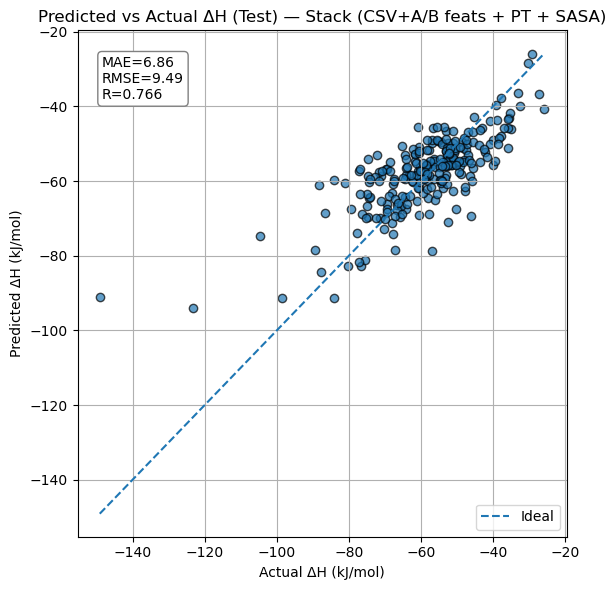

[INFO] Saved plot to: runs/dh_combo_csv_pt/pred_vs_actual_test_stack_combo_dh.png

=== Largest ΔH outliers on TEST set (by |residual|) ===
pdb_id  actual_dH    pred_dH   residual  |residual| model
  2f5z    -149.08 -91.096215 -57.983785   57.983785 Stack
  4per    -104.70 -74.616909 -30.083091   30.083091 Stack
  4dpg    -123.33 -93.883422 -29.446578   29.446578 Stack
  3g9v     -88.39 -61.118324 -27.271676   27.271676 Stack
  4gaf     -84.17 -59.803040 -24.366960   24.366960 Stack
  2tgp     -46.04 -69.362112  23.322112   23.322112 Stack
  1w1w     -56.92 -78.661990  21.741990   21.741990 Stack
  3g7z     -74.82 -54.216996 -20.603004   20.603004 Stack
  6u2h     -81.10 -60.530140 -20.569860   20.569860 Stack
  2qc1     -76.83 -56.716280 -20.113720   20.113720 Stack
  5ius     -77.17 -57.201873 -19.968127   19.968127 Stack
  2za4     -72.15 -53.008812 -19.141188   19.141188 Stack
  2wpt     -52.38 -70.934391  18.554391   18.554391 Stack
  5ifs     -86.51 -68.600570 -17.909430   17.9094

In [3]:
# ============================================
# ΔH Combo: CSV(A/B) + engineered feats + PT(mGLI) + SASA (robust) with delta_H targets
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr, pearsonr  # <-- added pearsonr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"  # one per line
TARGETS    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"
OUT_DIR    = "./runs/dh_combo_csv_pt"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- EXTRA (SASA) ----
SASA_PATH        = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_processing/all_pdb_sasa.txt"
USE_SASA_FEATURE = True  # toggle SASA on/off

# ---- SETTINGS ----
SEED                         = 42
VAL_SPLIT                    = 0.15
TEST_SPLIT                   = 0.15
USE_BFACTORS_AS_FEATURES     = True
USE_COMPLEX_COUNT_FEATURE    = True     # use the 'complex_count' scalar if available
K_BEST                       = 640      # feature selector after concatenation (tune 448–1024)
WINSORIZE_Y_QUANTILES        = None     # e.g., (0.01, 0.99) or None

# Models
N_TREES_RF = 800
N_TREES_ET = 1000
HGB_CFG = dict(learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
               min_samples_leaf=20, l2_regularization=0.2,
               max_bins=255, early_stopping=True,
               validation_fraction=0.15, n_iter_no_change=30, max_iter=1500)

# Stacking
N_SPLITS_STACK = 5
random.seed(SEED); np.random.seed(SEED)

# ---- CSV utils ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

# ---- PT utils ----
def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}: tried {cand1}" + (f" and {cand2}" if cand2 else ""))
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

# ---- SASA loader (robust) ----
def load_sasa_table(path: str) -> pd.DataFrame:
    """
    Load total SASA per complex and return a dataframe indexed by JOIN_ID
    with column 'total_sasa_A2' (Å^2). Derives JOIN_ID from BOTH 'pdb_id' and 'file'.
    """
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]

    # Standardize SASA column
    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")

    # Candidate 1: explicit pdb_id
    cand1 = None
    if "pdb_id" in df.columns:
        cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id)

    # Candidate 2: parse from path
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            # e.g., /.../PP2/1a22.ent.pdb -> 1a22
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)

    # Combine
    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")

    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()

    # Ensure numeric
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")

    # Aggregate duplicates by mean
    df = (df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"]
            .mean(numeric_only=True).to_frame())

    return df.sort_index()

# ---- Load targets (ΔH) ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]

# Normalize column names if needed
if "PDB_ID" in df_t.columns and "pdb_id" not in df_t.columns:
    df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
    if col in df_t.columns and "delta_H" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_H"})
for col in ("Delta_G", "ΔG_kJ/mol", "dG"):
    if col in df_t.columns and "delta_G" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_G"})

required = ["pdb_id", "delta_H"]
for c in required:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

# Optional scalar features from targets (e.g., size)
extra_scalar_cols = []
if USE_COMPLEX_COUNT_FEATURE and "complex_count" in df_t.columns:
    extra_scalar_cols.append("complex_count")
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---- Merge SASA (Å^2) into df_t and register as extra scalar feature ----
if USE_SASA_FEATURE:
    try:
        df_sasa = load_sasa_table(SASA_PATH)  # index = JOIN_ID
        before = df_t.shape[0]

        # Diagnostics BEFORE merge
        ids_t   = set(df_t["JOIN_ID"])
        ids_s   = set(df_sasa.index)
        inter   = ids_t & ids_s
        only_t  = sorted(ids_t - ids_s)
        only_s  = sorted(ids_s - ids_t)

        print(f"[SASA] df_t IDs: {len(ids_t)} | SASA IDs: {len(ids_s)} | Intersection: {len(inter)}")
        if only_t:
            miss_path = Path(OUT_DIR) / "sasa_missing_in_file_from_targets.txt"
            with open(miss_path, "w") as f:
                for x in only_t: f.write(x + "\n")
            print(f"[SASA] IDs present in targets but NOT in SASA: {len(only_t)} (saved {miss_path})")
        if only_s:
            extra_path = Path(OUT_DIR) / "sasa_not_used_extra_ids.txt"
            with open(extra_path, "w") as f:
                for x in only_s: f.write(x + "\n")
            print(f"[SASA] IDs present in SASA but NOT in filtered targets: {len(only_s)} (saved {extra_path})")

        # Merge by index
        df_t = df_t.merge(df_sasa, left_on="JOIN_ID", right_index=True, how="left")

        # Scale + register
        df_t["total_sasa_kA2"] = df_t["total_sasa_A2"] / 1000.0
        extra_scalar_cols.append("total_sasa_kA2")

        n_missing = df_t["total_sasa_kA2"].isna().sum()
        print(f"[INFO] SASA merged for {before - n_missing}/{before} rows (missing={n_missing}); "
              f"feature 'total_sasa_kA2' added.")
    except Exception as e:
        print(f"[WARN] Could not load/merge SASA: {e} — continuing without SASA.")

# ---- Load CSV A/B ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

# ---- Load PT vectors (mGLI) ----
pt_rows, missing, errors = [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

# Enforce mode length for PT vectors
lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(lengths) - len(pt_rows)} non-mode samples.")

# Make PT DF
pt_index  = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols   = [f"pt_{j}" for j in range(mode_len)]
df_pt     = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

# ---- Align: only keep IDs present everywhere
common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if not common:
    sys.exit("[FATAL] No common IDs across targets/CSV/PT.")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in CSV/PT.")

df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a = df_a.loc[sorted(common)]
df_b = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build feature matrix
A_all  = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all  = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(dtype=np.float64)
y_all  = df_t["delta_H"].to_numpy(dtype=np.float64).reshape(-1, 1)

# Engineered interactions
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT_all]

# Optional scalar features from TARGETS (size, B-factors, SASA)
extra_parts = []
if 'extra_scalar_cols' in locals() and extra_scalar_cols:
    extra_parts.append(df_t[extra_scalar_cols].to_numpy(dtype=np.float64))
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
if USE_BFACTORS_AS_FEATURES and bf_cols:
    extra_parts.append(df_t[bf_cols].to_numpy(dtype=np.float64))
if extra_parts:
    parts.extend(extra_parts)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified split on y (quantiles)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins
)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval)

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# ---- Common preprocessing (impute + K-best)
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else n_feat, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

def make_rf():
    return Pipeline(preproc() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(preproc() + [
        ("hgb", HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

def quick_eval(tag, mdl, X, y):
    p = mdl.predict(X)
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p); rho, _ = spearmanr(y, p)
    print(f"{tag}: R2={r2:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return p, {"R2": r2, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation (base) ==")
_ = quick_eval("VAL RF", rf, X_va, y_va)
_ = quick_eval("VAL ET", et, X_va, y_va)
_ = quick_eval("VAL HGB", hgb, X_va, y_va)

# ---- OOF stacking meta-features (7-d)
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---- Refit base models on TRAIN+VAL and evaluate
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

pred_te_rf  = rf.predict(X_te)
pred_te_et  = et.predict(X_te)
pred_te_hgb = hgb.predict(X_te)
pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

print("\n== Test (base & ensembles) ==")
_ = quick_eval("TEST RF", rf, X_te, y_te)
_ = quick_eval("TEST ET", et, X_te, y_te)
_ = quick_eval("TEST HGB", hgb, X_te, y_te)

# Select best ensemble by R2
def metrics_from(y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    return dict(R2=r2_score(y, p), MAE=mae, RMSE=rmse)

m_bl3 = metrics_from(y_te, pred_te_bl3)
m_st  = metrics_from(y_te, pred_te_st)
best_name, best_pred, best_metrics = ("Blend3", pred_te_bl3, m_bl3) if m_bl3["R2"] >= m_st["R2"] else ("Stack", pred_te_st, m_st)
print(f"TEST {best_name}: R2={best_metrics['R2']:.3f}  MAE={best_metrics['MAE']:.2f}  RMSE={best_metrics['RMSE']:.2f}")

# ---- Plot (annotate Pearson R instead of R²)
if X_te.size:
    # Compute Pearson R for the chosen (best) model
    try:
        R_val = float(pearsonr(y_te, best_pred)[0])
    except Exception:
        # Fallback in case of SciPy version quirks
        R_val = float(np.corrcoef(y_te, best_pred)[0, 1])

    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔH (kJ/mol)"); plt.ylabel("Predicted ΔH (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔH (Test) — {best_name} (CSV+A/B feats + PT + SASA)")
    txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR={R_val:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / f"pred_vs_actual_test_{best_name.lower()}_combo_dh.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Empty test set; skipping plot.")

# ==== Identify largest outliers (by absolute error) and their PDB IDs ====

# 1) Recreate the exact test ID split using the same seeds & stratification
ids_all = df_t["JOIN_ID"].to_numpy()
ids_trainval, ids_te, _, _ = train_test_split(
    ids_all, y_all, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins
)

# 2) Choose the ensemble we already selected above
y_true = y_te
y_pred = best_pred  # from the "best_name/best_pred" logic already computed

# 3) Compute residuals and rank by absolute error
residuals = y_true - y_pred
abs_err = np.abs(residuals)
order = np.argsort(-abs_err)   # descending by |error|

TOP_K = 20  # change if you want more/less
top_idx = order[:TOP_K]

# 4) Collect a table with IDs and errors
outlier_rows = []
for i in top_idx:
    outlier_rows.append({
        "pdb_id": ids_te[i],
        "actual_dH": float(y_true[i]),
        "pred_dH": float(y_pred[i]),
        "residual": float(residuals[i]),   # actual - pred
        "|residual|": float(abs_err[i]),
        "model": best_name
    })

outliers_df = pd.DataFrame(outlier_rows)
print("\n=== Largest ΔH outliers on TEST set (by |residual|) ===")
print(outliers_df.to_string(index=False))

# 5) Save to CSV for later use
csv_path = str(Path(OUT_DIR) / f"largest_outliers_test_{best_name.lower()}_combo_dh.csv")
outliers_df.to_csv(csv_path, index=False)
print(f"[INFO] Saved outliers to: {csv_path}")

# 6) If you also want all test points sorted by error, uncomment:
# all_df = pd.DataFrame({
#     "pdb_id": ids_te,
#     "actual_dH": y_true,
#     "pred_dH": y_pred,
#     "residual": residuals,
#     "|residual|": abs_err,
#     "model": best_name
# }).sort_values("|residual|", ascending=False)
# all_df.to_csv(Path(OUT_DIR) / f"all_test_residuals_{best_name.lower()}_combo_dh.csv", index=False)


[INFO] Using 1617/1831 target rows present in TXT (1617 allowed IDs).
[SASA] df_t IDs: 1617 | SASA IDs: 1462 | Intersection: 911
[INFO] SASA merged; missing=706
[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (1617, 94) B: (1617, 94) PT: (1617, 1440) ESM:OFF  Targets: (1617, 7) Common: 1617
Shapes -> X_tr:(1131, 2101), X_va:(243, 2101), X_te:(243, 2101), y_tr:(1131,)

== Validation (base) ==
VAL RF: R2=0.446  PearsonR=0.677  Spearman=0.690  MAE=7.30  RMSE=9.68  MSE=93.79
VAL ET: R2=0.430  PearsonR=0.661  Spearman=0.677  MAE=7.27  RMSE=9.82  MSE=96.47
VAL HGB: R2=0.553  PearsonR=0.745  Spearman=0.742  MAE=6.86  RMSE=8.70  MSE=75.66

== OOF stacking ==
TEST RF: R2=0.488  PearsonR=0.740  Spearman=0.683  MAE=7.65  RMSE=10.43  MSE=108.78
TEST ET: R2=0.498  PearsonR=0.730  Spearman=0.672  MAE=7.47  RMSE=10.33  MSE=106.79
TEST HGB: R2=0.558  PearsonR=0.754  Spearman=0.692  MAE=7.31  RMSE=9.70  MSE=94.05

TEST Blend3: R2=0.549  PearsonR=0.779  Spearman=0.715  MAE=7.09  R

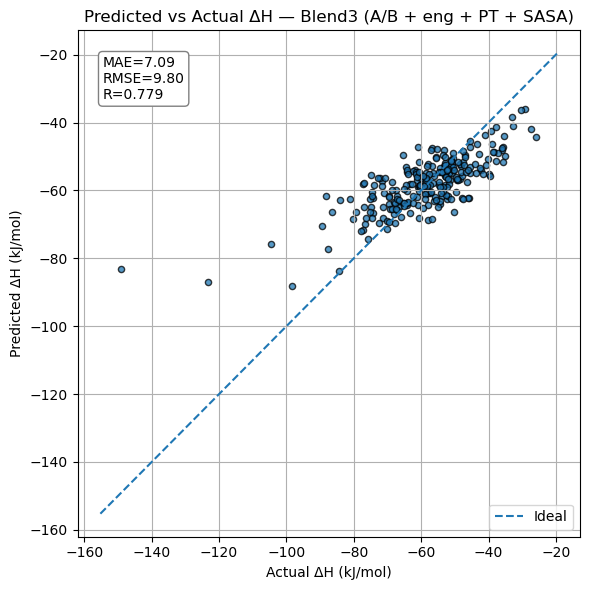

In [ ]:
#THE MODEL !!!!
#  ============================================
# ΔH Combo (no file outputs):
# CSV(A/B) + engineered feats + PT(mGLI) + SASA (+ ESM CSV) with delta_H targets
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
CSV_ESM    = "/vast/palmer/home.mccleary/op98/protein_design/dataset/PP/dd_esm_v2020.csv"  # NEW: ESM features
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TARGETS    = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"  # delta_H targets

# ---- EXTRA (SASA) ----
SASA_PATH        = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_processing/all_pdb_sasa.txt"
USE_SASA_FEATURE = True
USE_ESM_FEATURE  = False   # toggle ESM on/off

# ---- SETTINGS ----
SEED                      = 42
VAL_SPLIT                 = 0.15
TEST_SPLIT                = 0.15
USE_BFACTORS_AS_FEATURES  = True
USE_COMPLEX_COUNT_FEATURE = True
K_BEST                    = 640          # keep as in your original (tune 448–1024 if desired)
WINSORIZE_Y_QUANTILES     = None

# Models (same spirit)
N_TREES_RF = 800
N_TREES_ET = 1000
HGB_CFG = dict(
    learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=0.2,
    max_bins=255, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=30, max_iter=1500
)

# Stacking
N_SPLITS_STACK = 5
random.seed(SEED); np.random.seed(SEED)

# ---- CSV utils ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def load_feature_csv_flex(path: str, prefix: str = "feature_") -> pd.DataFrame:
    """ESM CSV may have an arbitrary number of feature_<int> columns."""
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    feat_cols = [c for c in df.columns if c.startswith(prefix) and c[len(prefix):].isdigit()]
    if not feat_cols:
        raise ValueError(f"{path}: no '{prefix}<int>' feature columns found.")
    feat_cols = sorted(feat_cols, key=lambda x: int(x.split("_")[1]))
    for c in feat_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[feat_cols].mean(numeric_only=True)
    return df.sort_index()

# ---- PT utils ----
def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try: return to_1d_numpy(v)
            except Exception: continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  arr = arr.reshape(1)
    if arr.ndim > 1:   arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}")
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

# ---- SASA loader (robust, no file writes) ----
def load_sasa_table(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")
    cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id) if "pdb_id" in df.columns else None
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)
    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")
    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"].mean(numeric_only=True).to_frame()
    return df.sort_index()

# ---- Load targets (ΔH) ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns and "pdb_id" not in df_t.columns:
    df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
    if col in df_t.columns and "delta_H" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_H"})
for col in ("Delta_G", "ΔG_kJ/mol", "dG"):
    if col in df_t.columns and "delta_G" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_G"})
required = ["pdb_id", "delta_H"]
for c in required:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_scalar_cols = []
if USE_COMPLEX_COUNT_FEATURE and "complex_count" in df_t.columns:
    extra_scalar_cols.append("complex_count")
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---- Merge SASA into df_t (and register as extra scalar) ----
if USE_SASA_FEATURE:
    try:
        df_sasa = load_sasa_table(SASA_PATH)
        ids_t = set(df_t["JOIN_ID"]); ids_s = set(df_sasa.index)
        inter = ids_t & ids_s
        print(f"[SASA] df_t IDs: {len(ids_t)} | SASA IDs: {len(ids_s)} | Intersection: {len(inter)}")
        df_t = df_t.merge(df_sasa, left_on="JOIN_ID", right_index=True, how="left")
        df_t["total_sasa_kA2"] = df_t["total_sasa_A2"] / 1000.0
        extra_scalar_cols.append("total_sasa_kA2")
        n_missing = df_t["total_sasa_kA2"].isna().sum()
        print(f"[INFO] SASA merged; missing={n_missing}")
    except Exception as e:
        print(f"[WARN] Could not load/merge SASA: {e} — continuing without SASA.")

# ---- Load CSV A/B/ESM ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)
if USE_ESM_FEATURE:
    try:
        df_esm = load_feature_csv_flex(CSV_ESM)
        print(f"[ESM] Loaded ESM features with shape {df_esm.shape}")
    except Exception as e:
        print(f"[WARN] Could not load ESM features: {e} — continuing without ESM.")
        USE_ESM_FEATURE = False
        df_esm = None

# ---- Load PT vectors (mGLI) ----
pt_rows, missing, errors = [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))
if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(lengths) - len(pt_rows)} non-mode samples.")
pt_index  = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols   = [f"pt_{j}" for j in range(mode_len)]
df_pt     = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

# ---- Align: only keep IDs present everywhere
common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if USE_ESM_FEATURE and df_esm is not None:
    common = common & set(df_esm.index)
if not common:
    sys.exit("[FATAL] No common IDs across required sources (targets/CSV/PT[/ESM]).")
if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in all required sources.")

df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a = df_a.loc[sorted(common)]
df_b = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]
if USE_ESM_FEATURE and df_esm is not None:
    df_esm = df_esm.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape,
      "ESM:" if USE_ESM_FEATURE and df_esm is not None else "ESM:OFF",
      (df_esm.shape if USE_ESM_FEATURE and df_esm is not None else ""), "Targets:", df_t.shape,
      "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build feature matrix (A/B engineered + PT + optional ESM + scalars)
A_all  = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all  = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(dtype=np.float64)
y_all  = df_t["delta_H"].to_numpy(dtype=np.float64).reshape(-1, 1)

# Engineered interactions (same as original)
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT_all]

# ESM block appended as-is
if USE_ESM_FEATURE and df_esm is not None:
    ESM_all = df_esm.loc[df_t["JOIN_ID"]].to_numpy(dtype=np.float64)
    parts.append(ESM_all)

# Optional scalar features
extra_parts = []
if 'extra_scalar_cols' in locals() and extra_scalar_cols:
    extra_parts.append(df_t[extra_scalar_cols].to_numpy(dtype=np.float64))
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
if USE_BFACTORS_AS_FEATURES and bf_cols:
    extra_parts.append(df_t[bf_cols].to_numpy(dtype=np.float64))
if extra_parts:
    parts.extend(extra_parts)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified split on y (quantiles)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

X_trainval, X_te, y_trainval, y_te, bins_trainval, _ = train_test_split(
    X_all, y_all, y_bins, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins
)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED, stratify=bins_trainval
)
print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# ---- Common preprocessing (impute + K-best)
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else n_feat, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

def make_rf():
    return Pipeline(preproc() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True, oob_score=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(preproc() + [
        ("hgb", HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

def quick_eval(tag, mdl, X, y, verbose=True):
    p = mdl.predict(X)
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p); rho, _ = spearmanr(y, p)
    try:
        R = float(pearsonr(y, p)[0])
    except Exception:
        R = float(np.corrcoef(y, p)[0, 1])
    if verbose:
        print(f"{tag}: R2={r2:.3f}  PearsonR={R:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return p, {"R2": r2, "PearsonR": R, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation (base) ==")
_ = quick_eval("VAL RF", rf, X_va, y_va)
_ = quick_eval("VAL ET", et, X_va, y_va)
_ = quick_eval("VAL HGB", hgb, X_va, y_va)

# ---- OOF stacking meta-features (7-d) — same structure
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---- Refit base models on TRAIN+VAL and evaluate
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

pred_te_rf,  _ = quick_eval("TEST RF",  rf,  X_te, y_te)
pred_te_et,  _ = quick_eval("TEST ET",  et,  X_te, y_te)
pred_te_hgb, _ = quick_eval("TEST HGB", hgb, X_te, y_te)

pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

def metrics_full(y, p):
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2  = r2_score(y, p); rho, _ = spearmanr(y, p)
    try:
        R = float(pearsonr(y, p)[0])
    except Exception:
        R = float(np.corrcoef(y, p)[0, 1])
    return dict(R2=r2, MAE=mae, RMSE=rmse, MSE=mse, Spearman=rho, PearsonR=R)

m_bl3 = metrics_full(y_te, pred_te_bl3)
m_st  = metrics_full(y_te, pred_te_st)

# Pick best by Pearson R (as requested)
if m_bl3["PearsonR"] >= m_st["PearsonR"]:
    best_name, best_pred, best_metrics = "Blend3", pred_te_bl3, m_bl3
else:
    best_name, best_pred, best_metrics = "Stack", pred_te_st, m_st

print(f"\nTEST {best_name}: R2={best_metrics['R2']:.3f}  PearsonR={best_metrics['PearsonR']:.3f}  "
      f"Spearman={best_metrics['Spearman']:.3f}  MAE={best_metrics['MAE']:.2f}  RMSE={best_metrics['RMSE']:.2f}")

# ---- Plot (display only; DO NOT save) — annotate best Pearson R
if X_te.size:
    R_val = best_metrics["PearsonR"]
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.75, edgecolor="k", s=20)
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    pad = 0.05*(mx-mn+1e-8)
    plt.plot([mn-pad, mx+pad], [mn-pad, mx+pad], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔH (kJ/mol)"); plt.ylabel("Predicted ΔH (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔH — {best_name} (A/B + eng + PT"
              f"{' + ESM' if USE_ESM_FEATURE and df_esm is not None else ''}"
              f"{' + SASA' if USE_SASA_FEATURE else ''})")
    txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR={R_val:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
else:
    print("[INFO] Empty test set; skipping plot.")


[INFO] Using 1617/1831 target rows present in TXT (1617 allowed IDs).
[SASA] df_t IDs: 1617 | SASA IDs: 1462 | Intersection: 911
[INFO] SASA merged; missing=706
[INFO] Using PT vectors of length 1440; dropped 0 non-mode samples.
A: (1617, 94) B: (1617, 94) PT: (1617, 1440) ESM:OFF  Targets: (1617, 7) Common: 1617
Shapes -> X_tr:(1131, 2101), X_va:(243, 2101), X_te:(243, 2101), y_tr:(1131,)
[RF] OOB R2 (train): 0.41941361098532215

== Validation (base) ==
VAL RF: R2=0.446  PearsonR=0.677  Spearman=0.690  MAE=7.30  RMSE=9.68  MSE=93.79
VAL ET: R2=0.430  PearsonR=0.661  Spearman=0.677  MAE=7.27  RMSE=9.82  MSE=96.47
VAL HGB: R2=0.553  PearsonR=0.745  Spearman=0.742  MAE=6.86  RMSE=8.70  MSE=75.66

== OOF stacking ==
TEST RF: R2=0.488  PearsonR=0.740  Spearman=0.683  MAE=7.65  RMSE=10.43  MSE=108.78
TEST ET: R2=0.498  PearsonR=0.730  Spearman=0.672  MAE=7.47  RMSE=10.33  MSE=106.79
TEST HGB: R2=0.558  PearsonR=0.754  Spearman=0.692  MAE=7.31  RMSE=9.70  MSE=94.05

TEST Blend3: R2=0.549  Pe

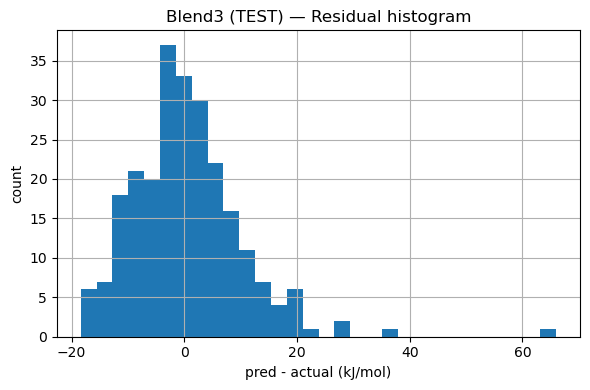

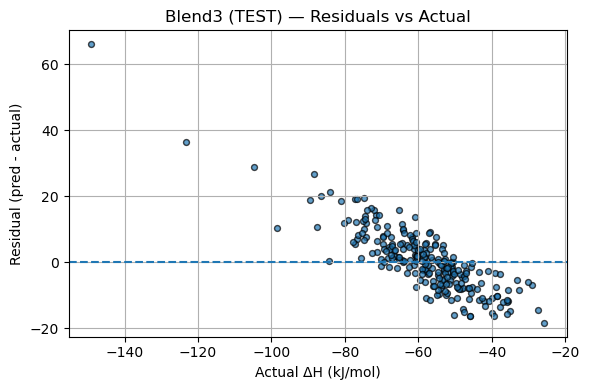

[INFO] QQ-ish plot skipped (erfinv not available).

== CV on TRAIN+VAL: RF (5-fold) ==
RF fold1: R2=0.276 R=0.534 MAE=7.86 RMSE=10.32
RF fold2: R2=0.441 R=0.672 MAE=7.98 RMSE=10.11
RF fold3: R2=0.430 R=0.690 MAE=8.07 RMSE=11.74
RF fold4: R2=0.442 R=0.684 MAE=7.72 RMSE=10.34
RF fold5: R2=0.505 R=0.722 MAE=7.01 RMSE=9.08
RF CV R2: 0.419 ± 0.085
RF CV PearsonR: 0.660 ± 0.073
RF CV Spearman: 0.649 ± 0.068
RF CV MAE: 7.73 ± 0.42
RF CV RMSE: 10.32 ± 0.95

== CV on TRAIN+VAL: ET (5-fold) ==
ET fold1: R2=0.285 R=0.544 MAE=7.77 RMSE=10.25
ET fold2: R2=0.439 R=0.666 MAE=7.93 RMSE=10.13
ET fold3: R2=0.463 R=0.708 MAE=7.78 RMSE=11.39
ET fold4: R2=0.454 R=0.688 MAE=7.56 RMSE=10.22
ET fold5: R2=0.509 R=0.718 MAE=6.95 RMSE=9.04
ET CV R2: 0.430 ± 0.085
ET CV PearsonR: 0.665 ± 0.070
ET CV Spearman: 0.649 ± 0.063
ET CV MAE: 7.60 ± 0.39
ET CV RMSE: 10.21 ± 0.83

== CV on TRAIN+VAL: HGB (5-fold) ==
HGB fold1: R2=0.426 R=0.658 MAE=7.01 RMSE=9.19
HGB fold2: R2=0.469 R=0.685 MAE=7.88 RMSE=9.85
HGB fold3: R2=

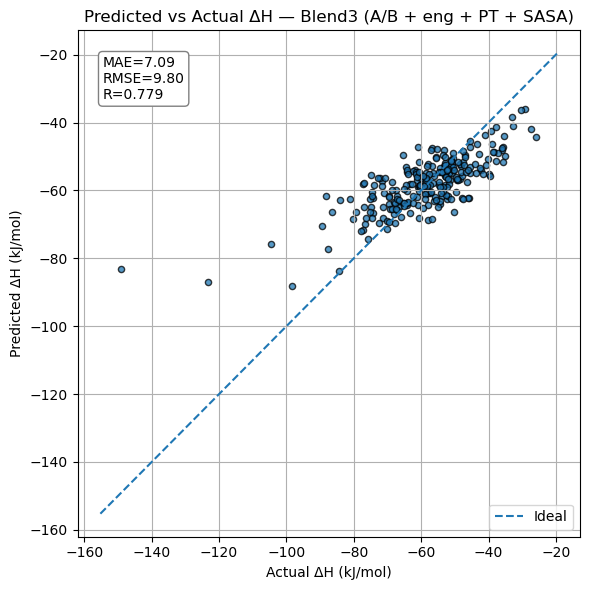

In [1]:
## MODEL + EXTRA STAT

# ============================================
# ΔH Combo (no file outputs) + EXTRA STATS
# CSV(A/B) + engineered feats + PT(mGLI) + SASA (+ ESM CSV) with delta_H targets
# ============================================

import os, re, sys, math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import torch
except Exception as e:
    print("[WARN] torch not available; PT feature loading will fail:", e)
    torch = None

# ---- PATHS (EDIT) ----
CSV_A      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B      = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
CSV_ESM    = "/vast/palmer/home.mccleary/op98/protein_design/dataset/PP/dd_esm_v2020.csv"  # NEW: ESM features
FEAT_DIR   = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2"  # {id}_mGLI.pt
PDB_TXT    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TARGETS    = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"

# ---- EXTRA (SASA) ----
SASA_PATH        = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_processing/all_pdb_sasa.txt"
USE_SASA_FEATURE = True
USE_ESM_FEATURE  = False   # toggle ESM on/off

# ---- SETTINGS ----
SEED                      = 42
VAL_SPLIT                 = 0.15
TEST_SPLIT                = 0.15
USE_BFACTORS_AS_FEATURES  = True
USE_COMPLEX_COUNT_FEATURE = True
K_BEST                    = 640          # keep as in your original (tune 448–1024 if desired)
WINSORIZE_Y_QUANTILES     = None

# Models (same spirit)
N_TREES_RF = 800
N_TREES_ET = 1000
HGB_CFG = dict(
    learning_rate=0.06, max_depth=4, max_leaf_nodes=63,
    min_samples_leaf=20, l2_regularization=0.2,
    max_bins=255, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=30, max_iter=1500
)

# Stacking
N_SPLITS_STACK = 5
random.seed(SEED); np.random.seed(SEED)

# ---- CSV utils ----
FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r'([0-9A-Za-z]{4})', s)
    return m.group(1).lower() if m else s.lower()

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): 
                continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: 
            return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def load_feature_csv_flex(path: str, prefix: str = "feature_") -> pd.DataFrame:
    """ESM CSV may have an arbitrary number of feature_<int> columns."""
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    feat_cols = [c for c in df.columns if c.startswith(prefix) and c[len(prefix):].isdigit()]
    if not feat_cols:
        raise ValueError(f"{path}: no '{prefix}<int>' feature columns found.")
    feat_cols = sorted(feat_cols, key=lambda x: int(x.split("_")[1]))
    for c in feat_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[feat_cols].mean(numeric_only=True)
    return df.sort_index()

# ---- PT utils ----
def to_1d_numpy(x) -> np.ndarray:
    if torch is not None and isinstance(x, torch.Tensor):
        arr = x.detach().cpu().numpy()
    elif isinstance(x, np.ndarray):
        arr = x
    elif isinstance(x, (list, tuple)):
        arr = np.asarray(x)
    elif isinstance(x, dict):
        keys = {k.lower(): k for k in x.keys()}
        for k in ["features", "feat", "x", "vec", "data", "emb", "embedding"]:
            if k in keys: 
                return to_1d_numpy(x[keys[k]])
        for _, v in x.items():
            try: 
                return to_1d_numpy(v)
            except Exception: 
                continue
        raise ValueError("No usable feature array found in dict payload.")
    else:
        raise TypeError(f"Unsupported payload type: {type(x)}")

    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim == 0:  
        arr = arr.reshape(1)
    if arr.ndim > 1:   
        arr = arr.reshape(-1)
    return arr

def load_pt_vector(feat_dir: str, pid: str) -> np.ndarray:
    if torch is None:
        raise RuntimeError("torch not available to load PT features.")
    pid_lc = pid.lower()
    cand1 = Path(feat_dir) / f"{pid_lc}_mGLI.pt"
    cand2 = Path(feat_dir) / f"{pid}_mGLI.pt" if pid != pid_lc else None
    p = cand1 if cand1.exists() else (cand2 if cand2 and cand2.exists() else None)
    if p is None:
        raise FileNotFoundError(f"Missing PT file for {pid}")
    try:
        obj = torch.load(str(p), map_location="cpu", weights_only=True)
    except TypeError:
        obj = torch.load(str(p), map_location="cpu")
    return to_1d_numpy(obj)

# ---- SASA loader (robust, no file writes) ----
def load_sasa_table(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    if "total_sasa_A2" not in df.columns:
        for alt in ("total_sasa", "total_sasa_A^2", "total_sasa_A²", "sasa_total_A2"):
            if alt in df.columns:
                df = df.rename(columns={alt: "total_sasa_A2"})
                break
    if "total_sasa_A2" not in df.columns:
        raise ValueError(f"SASA file missing 'total_sasa_A2' (got: {list(df.columns)})")

    cand1 = df["pdb_id"].astype(str).map(normalize_pdb_id) if "pdb_id" in df.columns else None
    cand2 = None
    if "file" in df.columns:
        def id_from_path(p: str) -> str:
            m = re.search(r'([0-9A-Za-z]{4})', str(p))
            return m.group(1).lower() if m else ""
        cand2 = df["file"].astype(str).map(id_from_path)

    if cand1 is not None and cand2 is not None:
        join_id = np.where(cand1.str.fullmatch(r"[0-9a-z]{4}", na=False), cand1, cand2)
    elif cand1 is not None:
        join_id = cand1
    elif cand2 is not None:
        join_id = cand2
    else:
        raise ValueError("No usable ID source in SASA file (need 'pdb_id' or 'file').")

    df = df.assign(JOIN_ID=join_id)
    df = df[df["JOIN_ID"].str.fullmatch(r"[0-9a-z]{4}", na=False)].copy()
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.groupby("JOIN_ID", as_index=True)["total_sasa_A2"].mean(numeric_only=True).to_frame()
    return df.sort_index()

# =========================================================
# EXTRA STATS HELPERS
# =========================================================
def metrics_full(y, p):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()

    err = p - y
    abs_err = np.abs(err)

    mse = mean_squared_error(y, p)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y, p)
    r2  = r2_score(y, p)

    rho, _ = spearmanr(y, p)
    try:
        R = float(pearsonr(y, p)[0])
    except Exception:
        R = float(np.corrcoef(y, p)[0, 1])

    medae = float(np.median(abs_err))
    p95ae = float(np.quantile(abs_err, 0.95))
    bias  = float(np.mean(err))
    sd    = float(np.std(err, ddof=1))
    skew  = float(((err - err.mean())**3).mean() / (err.std(ddof=0)**3 + 1e-12))

    denom = np.maximum(np.abs(y), 1.0)  # safe near 0
    mape_like = float(np.mean(abs_err / denom) * 100.0)

    return dict(
        R2=float(r2), MAE=float(mae), RMSE=float(rmse), MSE=float(mse),
        Spearman=float(rho), PearsonR=float(R),
        MedAE=medae, P95_AE=p95ae, Bias=bias, ResidSD=sd, ResidSkew=skew,
        MAPE_like_pct=mape_like,
        N=int(len(y))
    )

def print_metrics(tag, y, p):
    m = metrics_full(y, p)
    print(
        f"{tag}: "
        f"N={m['N']}  R2={m['R2']:.3f}  R={m['PearsonR']:.3f}  ρ={m['Spearman']:.3f}  "
        f"MAE={m['MAE']:.2f}  MedAE={m['MedAE']:.2f}  P95AE={m['P95_AE']:.2f}  "
        f"RMSE={m['RMSE']:.2f}  Bias={m['Bias']:.2f}  ResidSD={m['ResidSD']:.2f}  "
        f"MAPE~={m['MAPE_like_pct']:.1f}%"
    )
    return m

def residual_plots(y, p, title_prefix=""):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    res = p - y

    plt.figure(figsize=(6,4))
    plt.hist(res, bins=30)
    plt.title(f"{title_prefix} Residual histogram")
    plt.xlabel("pred - actual (kJ/mol)")
    plt.ylabel("count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.scatter(y, res, alpha=0.7, edgecolor="k", s=18)
    plt.axhline(0, linestyle="--")
    plt.title(f"{title_prefix} Residuals vs Actual")
    plt.xlabel("Actual ΔH (kJ/mol)")
    plt.ylabel("Residual (pred - actual)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # QQ-ish plot if erfinv exists
    try:
        from math import sqrt
        from numpy import erfinv
        res_sorted = np.sort((res - res.mean()) / (res.std(ddof=1) + 1e-12))
        n = len(res_sorted)
        q = np.linspace(0.5/n, 1-0.5/n, n)
        norm_q = sqrt(2) * erfinv(2*q - 1)

        plt.figure(figsize=(5,5))
        plt.scatter(norm_q, res_sorted, s=14, alpha=0.8, edgecolor="k")
        mn = float(min(norm_q.min(), res_sorted.min()))
        mx = float(max(norm_q.max(), res_sorted.max()))
        plt.plot([mn, mx], [mn, mx], linestyle="--")
        plt.title(f"{title_prefix} QQ-ish residuals (standardized)")
        plt.xlabel("Normal quantiles")
        plt.ylabel("Residual quantiles")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception:
        print("[INFO] QQ-ish plot skipped (erfinv not available).")

def error_by_bins(y, p, n_bins=7, tag=""):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    abs_err = np.abs(p - y)

    edges = np.quantile(y, np.linspace(0, 1, n_bins+1))
    edges = np.unique(edges)
    if len(edges) < 3:
        print(f"[WARN] Not enough unique y values for binning ({tag}).")
        return

    bin_idx = np.digitize(y, edges[1:-1], right=True)
    print(f"\n== Error by target quantile bins {tag} ==")
    for b in range(bin_idx.min(), bin_idx.max()+1):
        mask = bin_idx == b
        if mask.sum() == 0:
            continue
        lo = edges[b]
        hi = edges[b+1] if b+1 < len(edges) else edges[-1]
        print(
            f"Bin {b} [{lo:.2f}, {hi:.2f}]  n={mask.sum():3d}  "
            f"MAE={abs_err[mask].mean():.2f}  P95AE={np.quantile(abs_err[mask], 0.95):.2f}  "
            f"Bias={(p[mask]-y[mask]).mean():.2f}"
        )

def worst_errors(y, p, ids=None, topk=15, tag=""):
    y = np.asarray(y).ravel()
    p = np.asarray(p).ravel()
    abs_err = np.abs(p - y)
    worst = np.argsort(-abs_err)[:topk]
    print(f"\n== Worst absolute errors {tag} (top {topk}) ==")
    for i in worst:
        pid = ids[i] if ids is not None else f"idx={i}"
        print(f"{pid}  y={y[i]:8.2f}  pred={p[i]:8.2f}  err={p[i]-y[i]:+8.2f}  |err|={abs_err[i]:8.2f}")

def cv_eval(model_fn, X, y, name="MODEL", n_splits=5):
    print(f"\n== CV on TRAIN+VAL: {name} ({n_splits}-fold) ==")
    kf2 = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for fold, (tr_i, va_i) in enumerate(kf2.split(X, y), 1):
        mdl = model_fn()
        mdl.fit(X[tr_i], y[tr_i])
        pred = mdl.predict(X[va_i])
        m = metrics_full(y[va_i], pred)
        scores.append(m)
        print(f"{name} fold{fold}: R2={m['R2']:.3f} R={m['PearsonR']:.3f} MAE={m['MAE']:.2f} RMSE={m['RMSE']:.2f}")

    def mean_std(key):
        arr = np.array([s[key] for s in scores], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1))

    for key in ["R2", "PearsonR", "Spearman", "MAE", "RMSE"]:
        mu, sd = mean_std(key)
        if key in ["R2","PearsonR","Spearman"]:
            print(f"{name} CV {key}: {mu:.3f} ± {sd:.3f}")
        else:
            print(f"{name} CV {key}: {mu:.2f} ± {sd:.2f}")
    return scores

# ---- Load targets (ΔH) ----
df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns and "pdb_id" not in df_t.columns:
    df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
for col in ("Delta_H", "ΔH_kJ/mol", "dH"):
    if col in df_t.columns and "delta_H" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_H"})
for col in ("Delta_G", "ΔG_kJ/mol", "dG"):
    if col in df_t.columns and "delta_G" not in df_t.columns:
        df_t = df_t.rename(columns={col: "delta_G"})

required = ["pdb_id", "delta_H"]
for c in required:
    if c not in df_t.columns:
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_scalar_cols = []
if USE_COMPLEX_COUNT_FEATURE and "complex_count" in df_t.columns:
    extra_scalar_cols.append("complex_count")

bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# ---- Filter IDs by TXT ----
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# ---- Merge SASA into df_t (and register as extra scalar) ----
if USE_SASA_FEATURE:
    try:
        df_sasa = load_sasa_table(SASA_PATH)
        ids_t = set(df_t["JOIN_ID"]); ids_s = set(df_sasa.index)
        inter = ids_t & ids_s
        print(f"[SASA] df_t IDs: {len(ids_t)} | SASA IDs: {len(ids_s)} | Intersection: {len(inter)}")
        df_t = df_t.merge(df_sasa, left_on="JOIN_ID", right_index=True, how="left")
        df_t["total_sasa_kA2"] = df_t["total_sasa_A2"] / 1000.0
        extra_scalar_cols.append("total_sasa_kA2")
        n_missing = df_t["total_sasa_kA2"].isna().sum()
        print(f"[INFO] SASA merged; missing={n_missing}")
    except Exception as e:
        print(f"[WARN] Could not load/merge SASA: {e} — continuing without SASA.")
        USE_SASA_FEATURE = False

# ---- Load CSV A/B/ESM ----
df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)
if USE_ESM_FEATURE:
    try:
        df_esm = load_feature_csv_flex(CSV_ESM)
        print(f"[ESM] Loaded ESM features with shape {df_esm.shape}")
    except Exception as e:
        print(f"[WARN] Could not load ESM features: {e} — continuing without ESM.")
        USE_ESM_FEATURE = False
        df_esm = None

# ---- Load PT vectors (mGLI) ----
pt_rows, missing, errors = [], [], []
for pid in df_t["JOIN_ID"].tolist():
    try:
        v = load_pt_vector(FEAT_DIR, pid)
        pt_rows.append((pid, v))
    except FileNotFoundError:
        missing.append(pid)
    except Exception as e:
        errors.append((pid, str(e)))

if missing:
    print(f"[INFO] Missing PT for {len(missing)} IDs (e.g., {missing[:5]}) — dropping them.")
if errors:
    print(f"[WARN] Failed to parse {len(errors)} PT files (e.g., {errors[:2]}) — dropping them.")
if not pt_rows:
    sys.exit("[FATAL] No PT features loaded successfully.")

lengths = [len(v) for _, v in pt_rows]
mode_len = max(set(lengths), key=lengths.count)
pt_rows = [(i, v) for (i, v) in pt_rows if len(v) == mode_len]
print(f"[INFO] Using PT vectors of length {mode_len}; dropped {len(lengths) - len(pt_rows)} non-mode samples.")
pt_index  = [i for i, _ in pt_rows]
pt_matrix = np.vstack([v for _, v in pt_rows])
pt_cols   = [f"pt_{j}" for j in range(mode_len)]
df_pt     = pd.DataFrame(pt_matrix, index=pt_index, columns=pt_cols).sort_index()

# ---- Align: only keep IDs present everywhere
common = set(df_t["JOIN_ID"]) & set(df_a.index) & set(df_b.index) & set(df_pt.index)
if USE_ESM_FEATURE and df_esm is not None:
    common = common & set(df_esm.index)

if not common:
    sys.exit("[FATAL] No common IDs across required sources (targets/CSV/PT[/ESM]).")

if len(common) < len(df_t):
    print(f"[INFO] Dropping {len(df_t)-len(common)} targets not present in all required sources.")

df_t  = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)
df_a  = df_a.loc[sorted(common)]
df_b  = df_b.loc[sorted(common)]
df_pt = df_pt.loc[sorted(common)]
if USE_ESM_FEATURE and df_esm is not None:
    df_esm = df_esm.loc[sorted(common)]

print("A:", df_a.shape, "B:", df_b.shape, "PT:", df_pt.shape,
      "ESM:" if USE_ESM_FEATURE and df_esm is not None else "ESM:OFF",
      (df_esm.shape if USE_ESM_FEATURE and df_esm is not None else ""), "Targets:", df_t.shape,
      "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# ---- Build feature matrix (A/B engineered + PT + optional ESM + scalars)
A_all  = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all  = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
PT_all = df_pt.loc[df_t["JOIN_ID"], pt_cols].to_numpy(dtype=np.float64)
y_all  = df_t["delta_H"].to_numpy(dtype=np.float64).reshape(-1, 1)

# Engineered interactions (same as original)
SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)
RATIO = DIFF / (SUM + 1e-8)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS, RATIO, PT_all]

# ESM block appended as-is
if USE_ESM_FEATURE and df_esm is not None:
    ESM_all = df_esm.loc[df_t["JOIN_ID"]].to_numpy(dtype=np.float64)
    parts.append(ESM_all)

# Optional scalar features
extra_parts = []
if extra_scalar_cols:
    extra_parts.append(df_t[extra_scalar_cols].to_numpy(dtype=np.float64))
bf_cols = [c for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"] if c in df_t.columns]
if USE_BFACTORS_AS_FEATURES and bf_cols:
    extra_parts.append(df_t[bf_cols].to_numpy(dtype=np.float64))
if extra_parts:
    parts.extend(extra_parts)

X_all = np.hstack(parts).astype(np.float64)
y_all = y_all.ravel()

if WINSORIZE_Y_QUANTILES is not None:
    lo, hi = np.quantile(y_all, WINSORIZE_Y_QUANTILES)
    y_all = np.clip(y_all, lo, hi)

# ---- Stratified split on y (quantiles)
kbin = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='quantile')
y_bins = kbin.fit_transform(y_all.reshape(-1,1)).ravel()

idx_all = np.arange(len(y_all))
idx_trainval, idx_te = train_test_split(
    idx_all, test_size=TEST_SPLIT, random_state=SEED, stratify=y_bins
)

bins_trainval = y_bins[idx_trainval]
idx_tr, idx_va = train_test_split(
    idx_trainval,
    test_size=VAL_SPLIT/(1.0-TEST_SPLIT),
    random_state=SEED,
    stratify=bins_trainval
)

X_tr, y_tr = X_all[idx_tr], y_all[idx_tr]
X_va, y_va = X_all[idx_va], y_all[idx_va]
X_te, y_te = X_all[idx_te], y_all[idx_te]

# For reporting worst errors with IDs
ids_all = df_t["JOIN_ID"].tolist()
ids_tr = [ids_all[i] for i in idx_tr]
ids_va = [ids_all[i] for i in idx_va]
ids_te = [ids_all[i] for i in idx_te]

print(f"Shapes -> X_tr:{X_tr.shape}, X_va:{X_va.shape}, X_te:{X_te.shape}, y_tr:{y_tr.shape}")

# ---- Common preprocessing (impute + K-best)
n_feat = X_tr.shape[1]
k_use  = min(K_BEST if K_BEST is not None else n_feat, n_feat)

def preproc():
    return [
        ("imp", SimpleImputer(strategy="median")),
        ("k",   SelectKBest(score_func=f_regression, k=k_use)),
    ]

def make_rf():
    return Pipeline(preproc() + [
        ("rf", RandomForestRegressor(
            n_estimators=N_TREES_RF, max_features="sqrt",
            min_samples_leaf=3, bootstrap=True,
            oob_score=True,   # EXTRA STAT: OOB score
            n_jobs=-1, random_state=SEED))
    ])

def make_et():
    return Pipeline(preproc() + [
        ("et", ExtraTreesRegressor(
            n_estimators=N_TREES_ET, max_features="sqrt",
            min_samples_leaf=2, bootstrap=False,
            n_jobs=-1, random_state=SEED))
    ])

def make_hgb():
    return Pipeline(preproc() + [
        ("hgb", HistGradientBoostingRegressor(random_state=SEED, **HGB_CFG))
    ])

rf, et, hgb = make_rf(), make_et(), make_hgb()
rf.fit(X_tr, y_tr); et.fit(X_tr, y_tr); hgb.fit(X_tr, y_tr)

# OOB stat (RF only)
try:
    print("[RF] OOB R2 (train):", rf.named_steps["rf"].oob_score_)
except Exception:
    print("[RF] OOB R2 not available.")

def quick_eval(tag, mdl, X, y, verbose=True):
    p = mdl.predict(X)
    mse = mean_squared_error(y, p); rmse = np.sqrt(mse); mae = mean_absolute_error(y, p)
    r2 = r2_score(y, p); rho, _ = spearmanr(y, p)
    try:
        R = float(pearsonr(y, p)[0])
    except Exception:
        R = float(np.corrcoef(y, p)[0, 1])
    if verbose:
        print(f"{tag}: R2={r2:.3f}  PearsonR={R:.3f}  Spearman={rho:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  MSE={mse:.2f}")
    return p, {"R2": r2, "PearsonR": R, "Spearman": rho, "MAE": mae, "RMSE": rmse, "MSE": mse}

print("\n== Validation (base) ==")
_ = quick_eval("VAL RF", rf, X_va, y_va)
_ = quick_eval("VAL ET", et, X_va, y_va)
_ = quick_eval("VAL HGB", hgb, X_va, y_va)

# ---- OOF stacking meta-features (7-d) — same structure
print("\n== OOF stacking ==")
kf = KFold(n_splits=N_SPLITS_STACK, shuffle=True, random_state=SEED)
oof_meta = np.zeros((len(y_tr), 7))
test_meta = np.zeros((len(y_te), 7))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
    Xtr, Xva = X_tr[tr_idx], X_tr[va_idx]
    ytr, yva = y_tr[tr_idx], y_tr[va_idx]
    mrf, met, mhgb = make_rf(), make_et(), make_hgb()
    mrf.fit(Xtr, ytr); met.fit(Xtr, ytr); mhgb.fit(Xtr, ytr)

    prf = mrf.predict(Xva); pet = met.predict(Xva); phg = mhgb.predict(Xva)
    avg = (prf + pet + phg)/3.0
    oof_meta[va_idx, :] = np.column_stack([prf, pet, phg, avg, prf-pet, prf-phg, pet-phg])

    trf = mrf.predict(X_te); tet = met.predict(X_te); thg = mhgb.predict(X_te)
    tavg = (trf + tet + thg)/3.0
    test_meta += np.column_stack([trf, tet, thg, tavg, trf-tet, trf-thg, tet-thg]) / N_SPLITS_STACK

meta = Ridge(alpha=1.0, random_state=SEED)
meta.fit(oof_meta, y_tr)

# ---- Refit base models on TRAIN+VAL and evaluate
X_fit = np.vstack([X_tr, X_va]); y_fit = np.concatenate([y_tr, y_va])
rf.fit(X_fit, y_fit); et.fit(X_fit, y_fit); hgb.fit(X_fit, y_fit)

pred_te_rf,  _ = quick_eval("TEST RF",  rf,  X_te, y_te)
pred_te_et,  _ = quick_eval("TEST ET",  et,  X_te, y_te)
pred_te_hgb, _ = quick_eval("TEST HGB", hgb, X_te, y_te)

pred_te_bl3 = (pred_te_rf + pred_te_et + pred_te_hgb)/3.0
pred_te_st  = meta.predict(test_meta)

m_bl3 = metrics_full(y_te, pred_te_bl3)
m_st  = metrics_full(y_te, pred_te_st)

# Pick best by Pearson R
if m_bl3["PearsonR"] >= m_st["PearsonR"]:
    best_name, best_pred, best_metrics = "Blend3", pred_te_bl3, m_bl3
else:
    best_name, best_pred, best_metrics = "Stack", pred_te_st, m_st

print(f"\nTEST {best_name}: R2={best_metrics['R2']:.3f}  PearsonR={best_metrics['PearsonR']:.3f}  "
      f"Spearman={best_metrics['Spearman']:.3f}  MAE={best_metrics['MAE']:.2f}  RMSE={best_metrics['RMSE']:.2f}")

# =========================================================
# EXTRA TRAIN/VAL/TEST STATISTICS (detailed)
# =========================================================
print("\n== Extra stats: Train/Val/Test detailed metrics (base + blends) ==")

pred_tr_rf  = rf.predict(X_tr);  pred_va_rf  = rf.predict(X_va)
pred_tr_et  = et.predict(X_tr);  pred_va_et  = et.predict(X_va)
pred_tr_hgb = hgb.predict(X_tr); pred_va_hgb = hgb.predict(X_va)

print_metrics("TRAIN RF", y_tr, pred_tr_rf)
print_metrics("VAL   RF", y_va, pred_va_rf)
print_metrics("TEST  RF", y_te, pred_te_rf)

print_metrics("TRAIN ET", y_tr, pred_tr_et)
print_metrics("VAL   ET", y_va, pred_va_et)
print_metrics("TEST  ET", y_te, pred_te_et)

print_metrics("TRAIN HGB", y_tr, pred_tr_hgb)
print_metrics("VAL   HGB", y_va, pred_va_hgb)
print_metrics("TEST  HGB", y_te, pred_te_hgb)

pred_tr_bl3 = (pred_tr_rf + pred_tr_et + pred_tr_hgb)/3.0
pred_va_bl3 = (pred_va_rf + pred_va_et + pred_va_hgb)/3.0
print_metrics("TRAIN Blend3", y_tr, pred_tr_bl3)
print_metrics("VAL   Blend3", y_va, pred_va_bl3)
print_metrics("TEST  Blend3", y_te, pred_te_bl3)

# Stack diagnostics on TRAIN/VAL (NOT leakage-free; just sanity checks)
meta_tr = np.column_stack([
    pred_tr_rf, pred_tr_et, pred_tr_hgb,
    (pred_tr_rf+pred_tr_et+pred_tr_hgb)/3.0,
    pred_tr_rf-pred_tr_et, pred_tr_rf-pred_tr_hgb, pred_tr_et-pred_tr_hgb
])
meta_va = np.column_stack([
    pred_va_rf, pred_va_et, pred_va_hgb,
    (pred_va_rf+pred_va_et+pred_va_hgb)/3.0,
    pred_va_rf-pred_va_et, pred_va_rf-pred_va_hgb, pred_va_et-pred_va_hgb
])
pred_tr_st = meta.predict(meta_tr)
pred_va_st = meta.predict(meta_va)

print_metrics("TRAIN Stack", y_tr, pred_tr_st)
print_metrics("VAL   Stack", y_va, pred_va_st)
print_metrics("TEST  Stack", y_te, pred_te_st)

# Bin-wise + worst errors (TEST)
error_by_bins(y_te, best_pred, n_bins=7, tag=f"(TEST) — {best_name}")
worst_errors(y_te, best_pred, ids=ids_te, topk=15, tag=f"(TEST) — {best_name}")

# Residual plots (TEST)
residual_plots(y_te, best_pred, title_prefix=f"{best_name} (TEST) —")

# CV on TRAIN+VAL (no leakage from TEST)
_ = cv_eval(make_rf,  X_fit, y_fit, name="RF",  n_splits=5)
_ = cv_eval(make_et,  X_fit, y_fit, name="ET",  n_splits=5)
_ = cv_eval(make_hgb, X_fit, y_fit, name="HGB", n_splits=5)

# ---- Plot (display only; DO NOT save) — annotate best Pearson R
if X_te.size:
    R_val = best_metrics["PearsonR"]
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, best_pred, alpha=0.75, edgecolor="k", s=20)
    mn, mx = float(np.min([y_te.min(), best_pred.min()])), float(np.max([y_te.max(), best_pred.max()]))
    pad = 0.05*(mx-mn+1e-8)
    plt.plot([mn-pad, mx+pad], [mn-pad, mx+pad], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔH (kJ/mol)"); plt.ylabel("Predicted ΔH (kJ/mol)")
    plt.title(f"Predicted vs Actual ΔH — {best_name} (A/B + eng + PT"
              f"{' + ESM' if USE_ESM_FEATURE and 'df_esm' in globals() and df_esm is not None else ''}"
              f"{' + SASA' if USE_SASA_FEATURE else ''})")
    txt = f"MAE={best_metrics['MAE']:.2f}\nRMSE={best_metrics['RMSE']:.2f}\nR={R_val:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
else:
    print("[INFO] Empty test set; skipping plot.")

# =========================================================
# OPTIONAL MODEL SAVING (commented out; DOES write a file)
# =========================================================
# If you DO want to save later for benchmarking, uncomment:
# import joblib
# bundle = {
#     "rf": rf, "et": et, "hgb": hgb, "meta": meta,
#     "k_use": k_use, "pt_dim": mode_len,
#     "use_sasa": USE_SASA_FEATURE, "use_esm": USE_ESM_FEATURE,
#     "extra_scalar_cols": extra_scalar_cols, "bf_cols": bf_cols,
# }
# joblib.dump(bundle, "deltaH_combo_model.joblib")
# print("[INFO] Saved: deltaH_combo_model.joblib")


In [3]:
# --- Save trained models to a chosen location (run after training finishes) ---
import os, joblib

save_path = save_path = "/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model.joblib"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

bundle = {
    "rf": rf,
    "et": et,
    "hgb": hgb,
    "meta": meta,
    "k_use": k_use,
    "pt_dim": mode_len,
    "use_sasa": USE_SASA_FEATURE,
    "use_esm": USE_ESM_FEATURE,
    "extra_scalar_cols": extra_scalar_cols,
    "bf_cols": bf_cols,
    "feature_cols_AB": FEATURE_COLS,
}

joblib.dump(bundle, save_path)
print("Saved model bundle to:", save_path)


Saved model bundle to: /vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/model/deltaH_combo_model.joblib


In [ ]:
#CHECKS FOR NMR STRUCTURES IN PP INDEX
# Path to the PP index file (edit if needed)
index_path = "/vast/palmer/home.mccleary/op98/protein_design/dataset/PP/PP2/index/INDEX_general_PP.2020"

# Output file (written in the current working directory)
out_path = "nmr_pdb_ids.txt"

pdb_ids = []
with open(index_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        s = line.strip()
        # Skip comments/headers and blank lines
        if not s or s.startswith("#"):
            continue
        # Tokenize by any whitespace
        toks = s.split()
        # Expect: [pdb, resolution, year, binding, ...]
        if len(toks) >= 2:
            resolution = toks[1].upper()
            # Accept exact "NMR" or any token that contains "NMR" (e.g., "NMR-NEF")
            if "NMR" in resolution:
                pdb_id = toks[0].lower()  # normalize to lowercase PDB codes
                pdb_ids.append(pdb_id)

# Deduplicate while preserving order
seen = set()
unique_pdb_ids = []
for pid in pdb_ids:
    if pid not in seen:
        seen.add(pid)
        unique_pdb_ids.append(pid)

# Write out
with open(out_path, "w", encoding="utf-8") as out:
    for pid in unique_pdb_ids:
        out.write(pid + "\n")

print(f"Wrote {len(unique_pdb_ids)} PDB IDs with NMR resolution to '{out_path}'.")
# Show a quick preview
print("First 10 IDs:", unique_pdb_ids[:10])


Wrote 200 PDB IDs with NMR resolution to 'nmr_pdb_ids.txt'.
First 10 IDs: ['1tba', '1ees', '1g5j', '1kbh', '1jsp', '1l8c', '1jgn', '1jh4', '1p9d', '1otr']


[INFO] Using 1619/2800 target rows present in TXT (1619 allowed IDs).
A: (2570, 94) B: (2570, 94) Targets: (1619, 8) Common: 1619
Shapes -> X_fit:(1377, 567) (train+val), X_te:(242, 567), y_fit:(1377,)

== Metrics ==
Train+Val (fit): {'MSE': 35.4949, 'MAE': 4.5194, 'RMSE': 5.9578, 'R2': 0.6793}
Test: {'MSE': 76.2046, 'MAE': 6.8022, 'RMSE': 8.7295, 'R2': 0.2823}


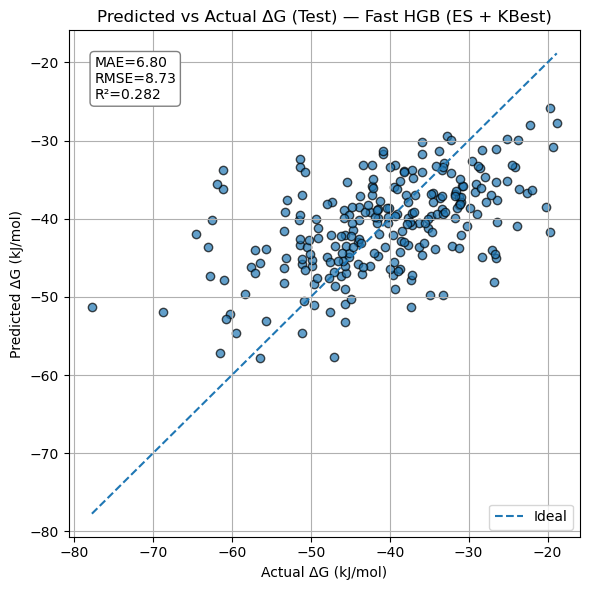

[INFO] Saved plot to: runs/dg_simple_best/pred_vs_actual_test_fast.png


In [4]:
# ============================================
# Fast, Regularized HGB w/ Early Stopping
# ============================================

# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"   # columns: ID + feature_1..feature_94
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"   # columns: ID + feature_1..feature_94
PDB_TXT     = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"   # one per line
TARGETS = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

OUT_DIR = "./runs/dg_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
USE_BFACT  = True

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

df_t = pd.read_csv(TARGETS, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]
if "PDB_ID" in df_t.columns: df_t = df_t.rename(columns={"PDB_ID": "pdb_id"})
if "ΔG_kJ/mol" in df_t.columns: df_t = df_t.rename(columns={"ΔG_kJ/mol": "delta_G"})
if "delta_G" not in df_t.columns and "Delta_G" in df_t.columns:
    df_t = df_t.rename(columns={"Delta_G": "delta_G"})

for c in ["pdb_id", "delta_G"]:
    if c not in df_t.columns: 
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

extra_cols = []
if USE_BFACT:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# Filter by TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# Keep only IDs present in both feature tables
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# 4) Feature matrix + splits

A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t["delta_G"].to_numpy(dtype=np.float64).reshape(-1, 1)

SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis=1) * np.linalg.norm(B_all, axis=1) + 1e-8)).reshape(-1,1)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)
y_all = y_all.ravel()

# Holdout splits (as before)
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

# We'll fit on TRAIN+VAL and let the model do its own early-stopping split
X_fit = np.vstack([X_tr, X_va]) if len(X_va) else X_tr
y_fit = np.concatenate([y_tr, y_va]) if len(y_va) else y_tr

print(f"Shapes -> X_fit:{X_fit.shape} (train+val), X_te:{X_te.shape}, y_fit:{y_fit.shape}")

# 5) Pipeline: Impute -> KBest(f_regression) -> HistGBR w/ early stopping

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("kbest",   SelectKBest(score_func=f_regression, k=min(256, X_fit.shape[1]))),
    ("hgb",     HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.07,
        max_depth=4,                 # shallow trees to reduce variance
        max_leaf_nodes=63,           # controls complexity
        min_samples_leaf=30,         # stronger regularization
        l2_regularization=0.3,       # shrink weights
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.15,    # internal split from X_fit
        n_iter_no_change=30,
        max_iter=1000,               # will stop early
        random_state=SEED
    ))
])

pipe.fit(X_fit, y_fit)

# 6) Evaluate

def eval_and_print(X, y, name):
    pred = pipe.predict(X) if X.size else np.array([])
    if pred.size == 0:
        print(f"{name}: [no samples]")
        return None, None
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics ==")
_ , _ = eval_and_print(X_fit, y_fit, "Train+Val (fit)")
pred_te, metrics_te = eval_and_print(X_te,  y_te,  "Test")

# 7) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel("Actual ΔG (kJ/mol)")
    plt.ylabel("Predicted ΔG (kJ/mol)")
    plt.title("Predicted vs Actual ΔG (Test) — Fast HGB (ES + KBest)")
    txt = f"MAE={metrics_te['MAE']:.2f}\nRMSE={metrics_te['RMSE']:.2f}\nR²={metrics_te['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_fast.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")

[INFO] Using 1619/1831 target rows present in TXT (1619 allowed IDs).
A: (2570, 94) B: (2570, 94) Targets: (1619, 5) Common: 1619
Shapes -> X_fit:(1377, 565) (train+val), X_te:(242, 565), y_fit:(1377,)

== Metrics ==
Train+Val (fit): {'MSE': 84.6555, 'MAE': 6.6499, 'RMSE': 9.2008, 'R2': 0.601}
Test: {'MSE': 115.3723, 'MAE': 7.9616, 'RMSE': 10.7412, 'R2': 0.294}


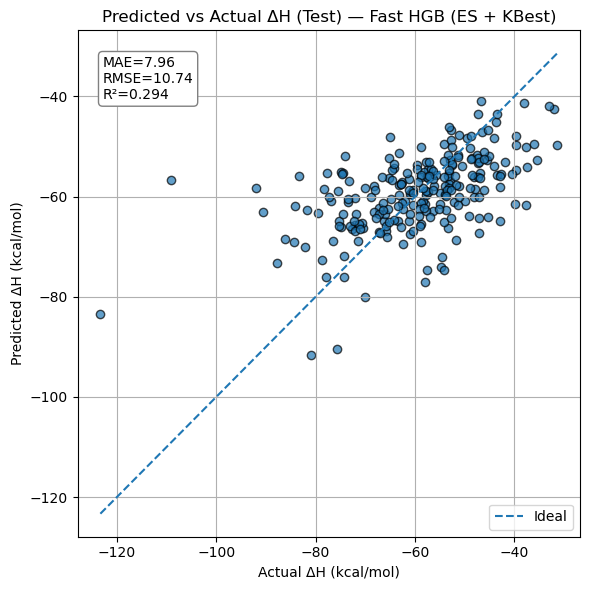

[INFO] Saved plot to: runs/dh_simple_best/pred_vs_actual_test_fast_deltaH.png


In [ ]:
#BIOPHYSICAL FEATURES ALONE IN PREDICTING DELTA H
#  ============================================
# Fast, Regularized HGB w/ Early Stopping — ΔH target
# ============================================

# 1) Imports & Config

import math, random, re, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- PATHS (EDIT) ----
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"   # columns: ID + feature_1..feature_94
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"   # columns: ID + feature_1..feature_94
PDB_TXT = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"   # one per line

# New: file that contains delta_H (generated earlier)
TARGETS_H = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_deltaH.txt"

OUT_DIR = "./runs/dh_simple_best"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ---- SETTINGS ----
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
USE_BFACT  = True

# Units label for plots/logs — change if your file is in kJ/mol
TARGET_COLUMN = "delta_H"
TARGET_UNITS  = "kcal/mol"

random.seed(SEED); np.random.seed(SEED)

# 2) Utilities

FEATURE_COLS = [f"feature_{i}" for i in range(1, 95)]

def normalize_pdb_id(x: str) -> str:
    s = str(x).strip().lower()
    m = re.search(r'([0-9a-z]{4})', s)
    return m.group(1) if m else s

def load_id_list(path: str) -> set[str]:
    ids = []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"): continue
            token = s.split()[0]
            ids.append(normalize_pdb_id(token))
    return {i for i in ids if re.fullmatch(r"[0-9a-z]{4}", i)}

def detect_id_col(cols):
    for k in ("ID", "pdb_id", "complex_id", "id"):
        if k in cols: return k
    raise ValueError(f"No ID column detected among: {cols}")

def load_feature_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    idc = detect_id_col(df.columns)
    missing = [c for c in FEATURE_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing features (e.g. {missing[:5]})")
    df = df[[idc] + FEATURE_COLS].copy()
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["JOIN_ID"] = df[idc].apply(normalize_pdb_id)
    df = df.groupby("JOIN_ID", as_index=True)[FEATURE_COLS].mean(numeric_only=True)
    return df.sort_index()

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = math.sqrt(mse)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

# 3) Load & align data

df_a = load_feature_csv(CSV_A)
df_b = load_feature_csv(CSV_B)

df_t = pd.read_csv(TARGETS_H, sep=None, engine="python")
df_t.columns = [c.strip() for c in df_t.columns]

# Normalize expected column names
rename_map = {}
if "PDB_ID" in df_t.columns:      rename_map["PDB_ID"] = "pdb_id"
if "Delta_H" in df_t.columns:     rename_map["Delta_H"] = "delta_H"
if "ΔH" in df_t.columns:          rename_map["ΔH"]     = "delta_H"
df_t = df_t.rename(columns=rename_map)

# Require columns
for c in ["pdb_id", TARGET_COLUMN]:
    if c not in df_t.columns: 
        raise ValueError(f"targets must contain '{c}' (got: {list(df_t.columns)})")

# Optional B-factors if present
extra_cols = []
if USE_BFACT:
    for c in ["Avg_Bfactor_Total", "Avg_Bfactor_Interface"]:
        if c in df_t.columns: extra_cols.append(c)

df_t["JOIN_ID"] = df_t["pdb_id"].apply(normalize_pdb_id)

# Filter by TXT list
allowed_ids = load_id_list(PDB_TXT)
before_txt = len(df_t)
df_t = df_t[df_t["JOIN_ID"].isin(allowed_ids)].reset_index(drop=True)
print(f"[INFO] Using {len(df_t)}/{before_txt} target rows present in TXT ({len(allowed_ids)} allowed IDs).")
if len(df_t) == 0:
    sys.exit("[FATAL] No targets remain after filtering by TXT list.")

# Keep only IDs present in both feature tables
common = set(df_a.index) & set(df_b.index) & set(df_t["JOIN_ID"])
dropped = len(df_t) - sum(df_t["JOIN_ID"].isin(common))
if dropped:
    print(f"[INFO] Dropping {dropped} target rows not present in both feature tables A & B.")
df_t = df_t[df_t["JOIN_ID"].isin(common)].reset_index(drop=True)

print("A:", df_a.shape, "B:", df_b.shape, "Targets:", df_t.shape, "Common:", len(common))
if len(df_t) < 10:
    print("[WARN] Very few samples after filtering—splits may be unstable.")

# 4) Feature matrix + splits

A_all = df_a.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
B_all = df_b.loc[df_t["JOIN_ID"], FEATURE_COLS].to_numpy(dtype=np.float64)
y_all = df_t[TARGET_COLUMN].to_numpy(dtype=np.float64).reshape(-1, 1)

SUM   = A_all + B_all
DIFF  = A_all - B_all
ADIFF = np.abs(DIFF)
PROD  = A_all * B_all
COS   = ((A_all * B_all).sum(axis=1) /
         (np.linalg.norm(A_all, axis1:=1) * np.linalg.norm(B_all, axis1) + 1e-8)).reshape(-1,1)
# note: Python <3.8 doesn't support :=; replace with two lines if needed:
# nA = np.linalg.norm(A_all, axis=1); nB = np.linalg.norm(B_all, axis=1)
# COS = ((A_all * B_all).sum(axis=1) / (nA * nB + 1e-8)).reshape(-1,1)

parts = [A_all, B_all, SUM, DIFF, ADIFF, PROD, COS]
if extra_cols:
    EX = df_t[extra_cols].to_numpy(dtype=np.float64)
    parts.append(EX)

X_all = np.hstack(parts)
y_all = y_all.ravel()

# Holdout splits (as before)
idx = list(range(len(df_t))); random.shuffle(idx)
n = len(idx); n_test = int(n*TEST_SPLIT); n_val = int(n*VAL_SPLIT)
test_idx = idx[:n_test]; val_idx = idx[n_test:n_test+n_val]; train_idx = idx[n_test+n_val:]

X_tr, y_tr = X_all[train_idx], y_all[train_idx]
X_va, y_va = X_all[val_idx],   y_all[val_idx]
X_te, y_te = X_all[test_idx],  y_all[test_idx]

# We'll fit on TRAIN+VAL and let the model do its own early-stopping split
X_fit = np.vstack([X_tr, X_va]) if len(X_va) else X_tr
y_fit = np.concatenate([y_tr, y_va]) if len(y_va) else y_tr

print(f"Shapes -> X_fit:{X_fit.shape} (train+val), X_te:{X_te.shape}, y_fit:{y_fit.shape}")

# 5) Pipeline: Impute -> KBest(f_regression) -> HistGBR w/ early stopping

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("kbest",   SelectKBest(score_func=f_regression, k=min(256, X_fit.shape[1]))),
    ("hgb",     HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.07,
        max_depth=4,                 # shallow trees to reduce variance
        max_leaf_nodes=63,           # controls complexity
        min_samples_leaf=30,         # stronger regularization
        l2_regularization=0.3,       # shrink weights
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.15,    # internal split from X_fit
        n_iter_no_change=30,
        max_iter=1000,               # will stop early
        random_state=SEED
    ))
])

pipe.fit(X_fit, y_fit)

# 6) Evaluate

def eval_and_print(X, y, name):
    pred = pipe.predict(X) if X.size else np.array([])
    if pred.size == 0:
        print(f"{name}: [no samples]")
        return None, None
    m = {
        "MSE": float(np.mean((pred - y)**2)),
        "MAE": float(np.mean(np.abs(pred - y))),
        "RMSE": float(np.sqrt(np.mean((pred - y)**2))),
        "R2": float(r2_score(y, pred)),
    }
    print(f"{name}: " + str({k: round(v, 4) for k, v in m.items()}))
    return pred, m

print("\n== Metrics ==")
_ , _ = eval_and_print(X_fit, y_fit, "Train+Val (fit)")
pred_te, metrics_te = eval_and_print(X_te,  y_te,  "Test")

# 7) Plot (Test)
if X_te.size:
    plt.figure(figsize=(6,6))
    plt.scatter(y_te, pred_te, alpha=0.7, edgecolor="k")
    mn, mx = float(np.min([y_te.min(), pred_te.min()])), float(np.max([y_te.max(), pred_te.max()]))
    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal")
    plt.xlabel(f"Actual ΔH ({TARGET_UNITS})")
    plt.ylabel(f"Predicted ΔH ({TARGET_UNITS})")
    plt.title("Predicted vs Actual ΔH (Test) — Fast HGB (ES + KBest)")
    txt = f"MAE={metrics_te['MAE']:.2f}\nRMSE={metrics_te['RMSE']:.2f}\nR²={metrics_te['R2']:.3f}"
    plt.annotate(txt, xy=(0.05,0.95), xycoords='axes fraction', va='top', ha='left',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray'))
    plt.legend(); plt.grid(True)
    plot_path = str(Path(OUT_DIR) / "pred_vs_actual_test_fast_deltaH.png")
    plt.tight_layout(); plt.savefig(plot_path, dpi=200); plt.show()
    print(f"[INFO] Saved plot to: {plot_path}")
else:
    print("[INFO] Skipping plot (empty test set).")


In [ ]:
## CHECKS THE PT FILES FOR NON-ZERO EMBEDDINGS AND COLLECTS VALID IDS
import os
import numpy as np
import torch

def collect_valid_ids(emb_dir, ids_file, out_file, n_check=None):
    """
    Collect IDs that have valid .pt embeddings 
    (file exists and embedding not all zeros).
    Saves valid IDs into out_file.
    """
    # Read PDB IDs from plain text file
    with open(ids_file, "r") as f:
        pdbs = [line.strip() for line in f if line.strip()]
    
    if n_check is None:
        n_check = len(pdbs)
    
    valid_ids = []
    
    for pdb in pdbs[:n_check]:
        path = os.path.join(emb_dir, f"{pdb}_mGLI.pt")
        if os.path.exists(path):
            emb = torch.load(path, weights_only=True)
            if isinstance(emb, dict):
                emb = next(iter(emb.values()))
            emb_flat = emb.flatten().cpu().numpy()
            if not np.all(emb_flat == 0):  # skip all-zeros
                valid_ids.append(pdb)
                print(f"{pdb}: VALID (min={emb_flat.min():.3f}, max={emb_flat.max():.3f})")
            else:
                print(f"{pdb}: all zeros -> skipped")
        else:
            print(f"{pdb}: File not found")
    
    # Save valid IDs to file
    with open(out_file, "w") as f:
        f.write("\n".join(valid_ids))
    
    print("\nSummary:")
    print(f"Total checked: {min(n_check, len(pdbs))}")
    print(f"Valid embeddings: {len(valid_ids)}")
    print(f"Invalid/missing: {min(n_check, len(pdbs)) - len(valid_ids)}")
    print(f"Saved valid IDs to {out_file}")
    
    return valid_ids

# Example usage:
valid_ids = collect_valid_ids(
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/pt2",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.from_filtered1.txt",
    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt",
    n_check=1619
)


1a22: VALID (min=0.000, max=9.430)
1acb: VALID (min=0.000, max=3.977)
1ak4: VALID (min=0.000, max=2.363)
1an1: VALID (min=0.000, max=2.851)
1atn: VALID (min=0.000, max=8.521)
1avx: VALID (min=0.000, max=5.604)
1avz: VALID (min=0.000, max=5.146)
1axi: VALID (min=0.000, max=8.909)
1ay7: VALID (min=0.000, max=4.603)
1azz: VALID (min=0.000, max=9.064)
1b6c: VALID (min=0.000, max=8.775)
1brs: VALID (min=0.000, max=0.054)
1buh: VALID (min=0.000, max=4.679)
1bvn: VALID (min=0.000, max=5.600)
1c9p: VALID (min=0.000, max=2.281)
1clv: VALID (min=0.000, max=2.677)
1cmx: VALID (min=0.000, max=8.457)
1cn4: VALID (min=0.000, max=5.320)
1d6r: VALID (min=0.000, max=2.925)
1dfj: VALID (min=0.000, max=4.001)
1dhk: VALID (min=0.000, max=13.099)
1djs: VALID (min=0.000, max=9.094)
1dp5: VALID (min=0.000, max=1.458)
1dpj: VALID (min=0.000, max=1.291)
1du3: VALID (min=0.000, max=6.805)
1dzb: VALID (min=0.000, max=7.259)
1e3u: VALID (min=0.000, max=12.276)
1e4k: VALID (min=0.000, max=6.978)
1e6e: VALID (min=0

1q5w: VALID (min=0.000, max=8.261)
1q68: VALID (min=0.000, max=5.747)
1q69: VALID (min=0.000, max=2.229)
1qa9: VALID (min=0.000, max=4.239)
1r0r: VALID (min=0.000, max=3.406)
1r6q: VALID (min=0.000, max=0.044)
1r8u: VALID (min=0.000, max=26.891)
1ri8: VALID (min=0.000, max=4.435)
1rjc: VALID (min=0.000, max=6.629)
1rkc: VALID (min=0.000, max=1.768)
1rke: VALID (min=0.000, max=2.217)
1rlb: VALID (min=0.000, max=3.590)
1rv6: VALID (min=0.000, max=4.938)
1ry7: VALID (min=0.000, max=9.266)
1s1q: VALID (min=0.000, max=5.673)
1s4y: VALID (min=0.000, max=5.668)
1sb0: VALID (min=0.000, max=4.665)
1sbb: VALID (min=0.000, max=1.686)
1sg1: VALID (min=0.000, max=6.736)
1shy: VALID (min=0.000, max=0.577)
1shz: VALID (min=0.000, max=8.824)
1smf: VALID (min=0.000, max=0.510)
1sq0: VALID (min=0.000, max=3.978)
1sv0: VALID (min=0.000, max=4.955)
1syq: VALID (min=0.000, max=0.979)
1t01: VALID (min=0.000, max=1.273)
1t0p: VALID (min=0.000, max=4.688)
1t44: VALID (min=0.000, max=0.768)
1t5z: VALID (min=0.

In [ ]:

## CHECKS THE PT FILES FOR NON-ZERO EMBEDDINGS AND COLLECTS VALID IDS
import pandas as pd

# === File paths ===
ids_path = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
tsv_path = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"

# === Load data ===
with open(ids_path, "r") as f:
    pdb_ids = [line.strip() for line in f if line.strip()]

df = pd.read_csv(tsv_path, sep="\t")

# Ensure consistent casing (some PDB IDs can be lowercase)
df["PDB_ID"] = df["PDB_ID"].str.strip().str.lower()
pdb_ids = [pid.lower() for pid in pdb_ids]

# === Check for non-zero values ===
valid_ids = []
invalid_ids = []

for pid in pdb_ids:
    row = df[df["PDB_ID"] == pid]
    if row.empty:
        print(f"{pid}: ❌ not found in TSV file")
        continue

    # Drop the ID column and check numeric values
    numeric_values = row.drop(columns=["PDB_ID"]).values.flatten()

    if (numeric_values == 0).any():
        print(f"{pid}: ⚠️ contains zero values")
        invalid_ids.append(pid)
    else:
        print(f"{pid}: ✅ all non-zero")
        valid_ids.append(pid)

# === Summary ===
print("\nSummary:")
print(f"Total IDs checked: {len(pdb_ids)}")
print(f"Found in TSV: {len(valid_ids) + len(invalid_ids)}")
print(f"All non-zero: {len(valid_ids)}")
print(f"Contain zeros or missing: {len(invalid_ids)}")


1a22: ✅ all non-zero
1acb: ✅ all non-zero
1ak4: ✅ all non-zero
1an1: ✅ all non-zero
1atn: ✅ all non-zero
1avx: ✅ all non-zero
1avz: ✅ all non-zero
1axi: ✅ all non-zero
1ay7: ✅ all non-zero
1azz: ✅ all non-zero
1b6c: ✅ all non-zero
1brs: ✅ all non-zero
1buh: ✅ all non-zero
1bvn: ✅ all non-zero
1c9p: ✅ all non-zero
1clv: ✅ all non-zero
1cmx: ✅ all non-zero
1cn4: ✅ all non-zero
1d6r: ✅ all non-zero
1dfj: ✅ all non-zero
1dhk: ✅ all non-zero
1djs: ✅ all non-zero
1dp5: ✅ all non-zero
1dpj: ✅ all non-zero
1du3: ✅ all non-zero
1dzb: ✅ all non-zero
1e3u: ✅ all non-zero
1e4k: ✅ all non-zero
1e6e: ✅ all non-zero
1e96: ✅ all non-zero
1eaw: ✅ all non-zero
1eer: ✅ all non-zero
1ees: ✅ all non-zero
1efn: ✅ all non-zero
1eja: ✅ all non-zero
1emv: ✅ all non-zero
1es0: ✅ all non-zero
1ewy: ✅ all non-zero
1ezs: ✅ all non-zero
1ezu: ✅ all non-zero
1f34: ✅ all non-zero
1f3v: ✅ all non-zero
1f5r: ✅ all non-zero
1f7z: ✅ all non-zero
1fc2: ✅ all non-zero
1ffw: ✅ all non-zero
1fg9: ✅ all non-zero
1fle: ✅ all n

In [ ]:
## CHECKS BIOPHYSICAL DATASETS FOR NON-ZERO VALUES AND COLLECTS VALID IDS
import pandas as pd
import numpy as np

# === File paths ===
IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TSV_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv"
CSV_A = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"

# === Load IDs ===
with open(IDS_FILE, "r") as f:
    pdb_ids = [line.strip().lower() for line in f if line.strip()]

# === Load datasets ===
df_tsv = pd.read_csv(TSV_FILE, sep="\t")
df_tsv["PDB_ID"] = df_tsv["PDB_ID"].str.strip().str.lower()

df_A = pd.read_csv(CSV_A)
df_B = pd.read_csv(CSV_B)

# Normalize ID column names
id_col_A = [c for c in df_A.columns if "id" in c.lower()][0]
id_col_B = [c for c in df_B.columns if "id" in c.lower()][0]
df_A[id_col_A] = df_A[id_col_A].astype(str).str.strip().str.lower()
df_B[id_col_B] = df_B[id_col_B].astype(str).str.strip().str.lower()

# === Function to test if all numeric values are non-zero ===
def all_nonzero(df, row_selector, exclude_cols=None):
    """Check if all numeric columns in selected row(s) are nonzero."""
    if exclude_cols is None:
        exclude_cols = []
    if df[row_selector].empty:
        return False
    values = df.loc[row_selector].drop(columns=exclude_cols).select_dtypes(include=[np.number]).values.flatten()
    if len(values) == 0:
        return False
    return np.all(values != 0)

# === Validation loop ===
valid_ids = []
invalid_ids = []

for pid in pdb_ids:
    found_all = True
    nonzero_all = True

    # --- binding_affinity_extended.tsv ---
    in_tsv = df_tsv["PDB_ID"] == pid
    if not in_tsv.any():
        print(f"{pid}: ❌ not found in binding_affinity_extended.tsv")
        found_all = False
    elif not all_nonzero(df_tsv, in_tsv, exclude_cols=["PDB_ID"]):
        print(f"{pid}: ⚠️ zeros in binding_affinity_extended.tsv")
        nonzero_all = False

    # --- dd_partnerA_biophysics ---
    in_A = df_A[id_col_A] == pid
    if not in_A.any():
        print(f"{pid}: ❌ not found in dd_partnerA_biophysics")
        found_all = False
    elif not all_nonzero(df_A, in_A, exclude_cols=[id_col_A]):
        print(f"{pid}: ⚠️ zeros in dd_partnerA_biophysics")
        nonzero_all = False

    # --- dd_partnerB_biophysics ---
    in_B = df_B[id_col_B] == pid
    if not in_B.any():
        print(f"{pid}: ❌ not found in dd_partnerB_biophysics")
        found_all = False
    elif not all_nonzero(df_B, in_B, exclude_cols=[id_col_B]):
        print(f"{pid}: ⚠️ zeros in dd_partnerB_biophysics")
        nonzero_all = False

    # --- Collect result ---
    if found_all and nonzero_all:
        print(f"{pid}: ✅ all datasets non-zero")
        valid_ids.append(pid)
    else:
        invalid_ids.append(pid)

# === Summary ===
print("\nSummary:")
print(f"Total IDs checked: {len(pdb_ids)}")
print(f"All non-zero across all datasets: {len(valid_ids)}")
print(f"Contain zeros / missing in at least one: {len(invalid_ids)}")


1a22: ✅ all datasets non-zero
1acb: ⚠️ zeros in dd_partnerB_biophysics
1ak4: ⚠️ zeros in dd_partnerB_biophysics
1an1: ⚠️ zeros in dd_partnerB_biophysics
1atn: ✅ all datasets non-zero
1avx: ✅ all datasets non-zero
1avz: ⚠️ zeros in dd_partnerB_biophysics
1axi: ✅ all datasets non-zero
1ay7: ⚠️ zeros in dd_partnerA_biophysics
1azz: ✅ all datasets non-zero
1b6c: ✅ all datasets non-zero
1brs: ⚠️ zeros in dd_partnerA_biophysics
1brs: ⚠️ zeros in dd_partnerB_biophysics
1buh: ⚠️ zeros in dd_partnerB_biophysics
1bvn: ✅ all datasets non-zero
1c9p: ⚠️ zeros in dd_partnerB_biophysics
1clv: ⚠️ zeros in dd_partnerB_biophysics
1cmx: ⚠️ zeros in dd_partnerB_biophysics
1cn4: ✅ all datasets non-zero
1d6r: ✅ all datasets non-zero
1dfj: ✅ all datasets non-zero
1dhk: ⚠️ zeros in dd_partnerB_biophysics
1djs: ✅ all datasets non-zero
1dp5: ⚠️ zeros in dd_partnerB_biophysics
1dpj: ⚠️ zeros in dd_partnerB_biophysics
1du3: ✅ all datasets non-zero
1dzb: ✅ all datasets non-zero
1e3u: ✅ all datasets non-zero
1e4k: 

In [ ]:
## COMPUTE AVERAGE COMPLEX COUNT AND FILTER BELOW AVERAGE
import pandas as pd

# === File paths ===
INPUT_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"
OUTPUT_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_below_avg_complex.tsv"

# === Load data ===
df = pd.read_csv(INPUT_FILE, sep=",")

# === Compute average complex_count ===
avg_complex = df["complex_count"].mean()
print(f"Average complex_count = {avg_complex:.2f}")

# === Filter rows with complex_count < average ===
filtered = df[df["complex_count"] < avg_complex].copy()

# === Select required columns and rename ===
filtered = filtered[["pdb_id", "delta_G"]].rename(
    columns={"pdb_id": "PDB_ID", "delta_G": "ΔG_kJ/mol"}
)

# === Save result ===
filtered.to_csv(OUTPUT_FILE, sep="\t", index=False)

print(f"\nSaved {len(filtered)} entries to {OUTPUT_FILE}")
print(filtered)


Average complex_count = 625.04

Saved 1234 entries to /home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_below_avg_complex.tsv
     PDB_ID  ΔG_kJ/mol
0      1fc2     -43.65
1      3sgb     -61.34
2      2tgp     -32.08
3      2ptc     -75.47
4      2sni     -66.77
...     ...        ...
1821   6ib8     -40.11
1822   6oqj     -45.92
1828   6n9d     -61.36
1829   6mav     -59.79
1830   6har     -58.30

[1234 rows x 2 columns]


In [26]:
import pandas as pd
import numpy as np

# === File paths ===
IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
CSV_A   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerA_biophysics_v2020.csv"
CSV_B   = "/home/op98/protein_design/dataset/PP/biochemical/dd_partnerB_biophysics_v2020.csv"
OUT_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/nonzero_in_biophysics_ids.txt"

# === Load IDs ===
with open(IDS_FILE, "r") as f:
    pdb_ids = [line.strip().lower() for line in f if line.strip()]

# === Load CSVs ===
df_A = pd.read_csv(CSV_A)
df_B = pd.read_csv(CSV_B)

# Find the ID column in each CSV
id_col_A = [c for c in df_A.columns if "id" in c.lower()][0]
id_col_B = [c for c in df_B.columns if "id" in c.lower()][0]

# Normalize IDs
df_A[id_col_A] = df_A[id_col_A].astype(str).str.strip().str.lower()
df_B[id_col_B] = df_B[id_col_B].astype(str).str.strip().str.lower()

# === Helper: check all numeric values are non-zero (zeros only, per request) ===
def all_nonzero_in_rows(df, row_selector, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    if df[row_selector].empty:
        return False
    vals = (
        df.loc[row_selector]
          .drop(columns=exclude_cols, errors="ignore")
          .select_dtypes(include=[np.number])
          .values
          .flatten()
    )
    if vals.size == 0:
        return False
    return np.all(vals != 0)

# === Validation loop (CSV-only) ===
valid_ids = []
invalid_ids = []
missing_any = 0

for pid in pdb_ids:
    in_A = (df_A[id_col_A] == pid)
    in_B = (df_B[id_col_B] == pid)

    if not in_A.any() or not in_B.any():
        print(f"{pid}: ❌ missing in A or B")
        missing_any += 1
        invalid_ids.append(pid)
        continue

    ok_A = all_nonzero_in_rows(df_A, in_A, exclude_cols=[id_col_A])
    ok_B = all_nonzero_in_rows(df_B, in_B, exclude_cols=[id_col_B])

    if ok_A and ok_B:
        print(f"{pid}: ✅ non-zero in both CSVs")
        valid_ids.append(pid)
    else:
        if not ok_A:
            print(f"{pid}: ⚠️ zeros in CSV A")
        if not ok_B:
            print(f"{pid}: ⚠️ zeros in CSV B")
        invalid_ids.append(pid)

# === Save valid IDs (CSV-only pass) ===
with open(OUT_FILE, "w") as f:
    f.write("\n".join(valid_ids))

# === Summary ===
print("\nSummary (CSV-only):")
print(f"Total IDs listed: {len(pdb_ids)}")
print(f"Missing in at least one CSV: {missing_any}")
print(f"Non-zero across both CSVs: {len(valid_ids)}")
print(f"Zeros in at least one CSV: {len(invalid_ids) - missing_any}")
print(f"Saved valid IDs to: {OUT_FILE}")


1a22: ✅ non-zero in both CSVs
1acb: ⚠️ zeros in CSV B
1ak4: ⚠️ zeros in CSV B
1an1: ⚠️ zeros in CSV B
1atn: ✅ non-zero in both CSVs
1avx: ✅ non-zero in both CSVs
1avz: ⚠️ zeros in CSV B
1axi: ✅ non-zero in both CSVs
1ay7: ⚠️ zeros in CSV A
1azz: ✅ non-zero in both CSVs
1b6c: ✅ non-zero in both CSVs
1brs: ⚠️ zeros in CSV A
1brs: ⚠️ zeros in CSV B
1buh: ⚠️ zeros in CSV B
1bvn: ✅ non-zero in both CSVs
1c9p: ⚠️ zeros in CSV B
1clv: ⚠️ zeros in CSV B
1cmx: ⚠️ zeros in CSV B
1cn4: ✅ non-zero in both CSVs
1d6r: ✅ non-zero in both CSVs
1dfj: ✅ non-zero in both CSVs
1dhk: ⚠️ zeros in CSV B
1djs: ✅ non-zero in both CSVs
1dp5: ⚠️ zeros in CSV B
1dpj: ⚠️ zeros in CSV B
1du3: ✅ non-zero in both CSVs
1dzb: ✅ non-zero in both CSVs
1e3u: ✅ non-zero in both CSVs
1e4k: ✅ non-zero in both CSVs
1e6e: ✅ non-zero in both CSVs
1e96: ✅ non-zero in both CSVs
1eaw: ⚠️ zeros in CSV B
1eer: ✅ non-zero in both CSVs
1ees: ⚠️ zeros in CSV B
1efn: ⚠️ zeros in CSV A
1eja: ⚠️ zeros in CSV B
1emv: ⚠️ zeros in CSV A
1emv

In [3]:
import pandas as pd
import numpy as np

# === File paths ===
VALID_IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.audit.txt"
ALL_IDS_FILE   = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TSV_FILE       = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"

# === Load ID lists ===
def load_ids(path):
    with open(path, "r") as f:
        return [line.strip().lower() for line in f if line.strip()]

valid_ids = load_ids(VALID_IDS_FILE)
all_ids   = load_ids(ALL_IDS_FILE)

# === Load TSV ===
df = pd.read_csv(TSV_FILE)
df.columns = [c.strip() for c in df.columns]

if "pdb_id" not in df.columns or "complex_count" not in df.columns:
    raise ValueError("TSV must include 'pdb_id' and 'complex_count' columns.")

df["pdb_id"] = df["pdb_id"].astype(str).str.lower()

# === Filter datasets ===
df_valid = df[df["pdb_id"].isin(valid_ids)].copy()
df_all   = df[df["pdb_id"].isin(all_ids)].copy()

# === Compute statistics ===
def describe_complex(df_sub, label):
    n = len(df_sub)
    mean = df_sub["complex_count"].mean()
    sd = df_sub["complex_count"].std()
    print(f"{label}:")
    print(f"  → n = {n}")
    print(f"  → mean = {mean:.2f}")
    print(f"  → sd = {sd:.2f}\n")
    return mean, sd, n

print("=== Complex Count Summary ===")
mean_valid, sd_valid, n_valid = describe_complex(df_valid, "603 IDs")
mean_all,   sd_all,   n_all   = describe_complex(df_all, "1619 IDs")

delta_mean = mean_valid - mean_all
print(f"Δ Difference (mean_valid - mean_all): {delta_mean:+.2f}")
print("==============================")

# === Optional: show top rows for inspection ===
display(df_valid[["pdb_id", "complex_count"]].head(10))
display(df_all[["pdb_id", "complex_count"]].head(10))


=== Complex Count Summary ===
603 IDs:
  → n = 603
  → mean = 341.03
  → sd = 252.73

1619 IDs:
  → n = 1619
  → mean = 531.33
  → sd = 508.42

Δ Difference (mean_valid - mean_all): -190.29


,pdb_id,complex_count
0,1fc2,251
1,3sgb,235
2,2tgp,281
3,2ptc,281
4,2sni,339
7,1acb,304
8,2pcc,804
9,2pcb,692
10,2sic,382
11,2cpk,353


,pdb_id,complex_count
0,1fc2,251
1,3sgb,235
2,2tgp,281
3,2ptc,281
4,2sni,339
5,1atn,629
6,1gla,650
7,1acb,304
8,2pcc,804
9,2pcb,692


In [4]:
import pandas as pd
import numpy as np
from scipy import stats

# === File paths ===
VALID_IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.audit.txt"
ALL_IDS_FILE   = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TSV_FILE       = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"

# === Load ID lists ===
def load_ids(path):
    with open(path, "r") as f:
        return [line.strip().lower() for line in f if line.strip()]

valid_ids = load_ids(VALID_IDS_FILE)
all_ids   = load_ids(ALL_IDS_FILE)

# === Load TSV ===
df = pd.read_csv(TSV_FILE)
df.columns = [c.strip() for c in df.columns]
if "pdb_id" not in df.columns or "complex_count" not in df.columns:
    raise ValueError("TSV must include 'pdb_id' and 'complex_count' columns.")

df["pdb_id"] = df["pdb_id"].astype(str).str.lower()

# === Filter & clean ===
df_valid = df[df["pdb_id"].isin(valid_ids)][["pdb_id", "complex_count"]].dropna().copy()
df_all   = df[df["pdb_id"].isin(all_ids)][["pdb_id", "complex_count"]].dropna().copy()

# === Basic stats ===
def describe_complex(s, label):
    n = s.size
    mean = s.mean()
    sd = s.std(ddof=1)
    print(f"{label}: n={n}, mean={mean:.2f}, sd={sd:.2f}")
    return mean, sd, n

print("=== Complex Count Summary ===")
mean_valid, sd_valid, n_valid = describe_complex(df_valid["complex_count"], "VALID IDs")
mean_all,   sd_all,   n_all   = describe_complex(df_all["complex_count"],   "1619 IDs")

delta_mean = mean_valid - mean_all
print(f"Δ mean (VALID - 1619): {delta_mean:+.2f}")

# === Welch's t-test (unequal variances) ===
t_stat, p_val = stats.ttest_ind(
    df_valid["complex_count"].values,
    df_all["complex_count"].values,
    equal_var=False, nan_policy="omit"
)

# Welch-Satterthwaite df
s1, s2 = sd_valid, sd_all
n1, n2 = n_valid, n_all
se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))

# 95% CI for mean difference
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=df_welch)
ci_lo, ci_hi = delta_mean - t_crit*se_diff, delta_mean + t_crit*se_diff

# Effect size: Hedges' g (bias-corrected Cohen's d)
# pooled SD with unequal n
sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))
d = (mean_valid - mean_all) / sp if sp > 0 else np.nan
J = 1 - (3 / (4*(n1 + n2) - 9))  # small-sample correction
g = J * d

print("\n=== Welch's t-test ===")
print(f"t = {t_stat:.4f}, df ≈ {df_welch:.1f}, p = {p_val:.4g}")
print(f"95% CI for Δ mean: [{ci_lo:.2f}, {ci_hi:.2f}]")
print(f"Effect size (Hedges' g): {g:.3f}")
print("==============================")

# (Optional) quick preview tables
display(df_valid.head(10))
display(df_all.head(10))


=== Complex Count Summary ===
VALID IDs: n=603, mean=341.03, sd=252.73
1619 IDs: n=1619, mean=531.33, sd=508.42
Δ mean (VALID - 1619): -190.29

=== Welch's t-test ===
t = -11.6768, df ≈ 2050.9, p = 1.515e-30
95% CI for Δ mean: [-222.25, -158.33]
Effect size (Hedges' g): -0.419


,pdb_id,complex_count
0,1fc2,251
1,3sgb,235
2,2tgp,281
3,2ptc,281
4,2sni,339
7,1acb,304
8,2pcc,804
9,2pcb,692
10,2sic,382
11,2cpk,353


,pdb_id,complex_count
0,1fc2,251
1,3sgb,235
2,2tgp,281
3,2ptc,281
4,2sni,339
5,1atn,629
6,1gla,650
7,1acb,304
8,2pcc,804
9,2pcb,692


In [5]:
import pandas as pd
import numpy as np
from scipy import stats

VALID_IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.audit.txt"
ALL_IDS_FILE   = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TSV_FILE       = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"

def load_ids(p):
    with open(p) as f:
        return [x.strip().lower() for x in f if x.strip()]

valid_ids = set(load_ids(VALID_IDS_FILE))
all_ids   = set(load_ids(ALL_IDS_FILE))
comp_ids  = all_ids - valid_ids        # complement

df = pd.read_csv(TSV_FILE)
df["pdb_id"] = df["pdb_id"].astype(str).str.lower()

valid_counts = df[df["pdb_id"].isin(valid_ids)]["complex_count"].dropna().to_numpy()
comp_counts  = df[df["pdb_id"].isin(comp_ids)]["complex_count"].dropna().to_numpy()

print(f"VALID n={valid_counts.size}, COMPLEMENT n={comp_counts.size}, overlap={len(valid_ids & all_ids)}")

def summarize(name, a):
    return f"{name}: mean={a.mean():.2f}, sd={a.std(ddof=1):.2f}, n={a.size}"

print(summarize("VALID", valid_counts))
print(summarize("COMPLEMENT", comp_counts))

# Welch t-test
t, p = stats.ttest_ind(valid_counts, comp_counts, equal_var=False)
s1, s2 = valid_counts.std(ddof=1), comp_counts.std(ddof=1)
n1, n2 = valid_counts.size, comp_counts.size
se = np.sqrt(s1**2/n1 + s2**2/n2)
df_w = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
delta = valid_counts.mean() - comp_counts.mean()
tcrit = stats.t.ppf(0.975, df=df_w)
ci = (delta - tcrit*se, delta + tcrit*se)

# Hedges' g
sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2)/(n1+n2-2))
d = (delta / sp) if sp>0 else np.nan
J = 1 - (3/(4*(n1+n2)-9))
g = J*d

print("\n=== VALID vs COMPLEMENT ===")
print(f"Welch t={t:.4f}, df≈{df_w:.1f}, p={p:.3g}")
print(f"Δ mean (VALID - COMPLEMENT) = {delta:.2f}  (95% CI: {ci[0]:.2f}, {ci[1]:.2f})")
print(f"Hedges' g = {g:.3f}")

# Nonparametric robustness (Mann–Whitney U)
u, p_u = stats.mannwhitneyu(valid_counts, comp_counts, alternative='two-sided')
print(f"Mann–Whitney U: U={u:.0f}, p={p_u:.3g}")


VALID n=603, COMPLEMENT n=1016, overlap=603
VALID: mean=341.03, sd=252.73, n=603
COMPLEMENT: mean=644.27, sd=583.00, n=1016

=== VALID vs COMPLEMENT ===
Welch t=-14.4486, df≈1505.1, p=2.07e-44
Δ mean (VALID - COMPLEMENT) = -303.23  (95% CI: -344.40, -262.07)
Hedges' g = -0.622
Mann–Whitney U: U=155166, p=4.91e-62


VALID  : {'n': 603, 'mean': 341.0348258706468, 'sd': 252.730846643113, 'median': 304.0, 'iqr': 200.5}
COMPLEMENT: {'n': 1016, 'mean': 644.2696850393701, 'sd': 582.9974728133037, 'median': 519.0, 'iqr': 462.0}
Cliff's delta: -0.493  (negative → VALID < COMPLEMENT)


Hodges–Lehmann (median diff, boot): -216.50  95% CI [-251.00, -180.50]


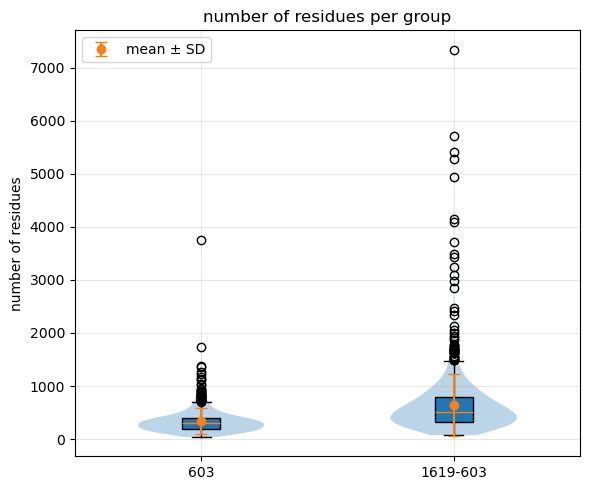

In [ ]:
## COMPUTE ROBUST STATS AND PLOT VIOLIN OF COMPLEX COUNTS IN TWO GROUPS
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Assumes you already have:
#   valid_counts  = np.array([...])
#   comp_counts   = np.array([...])

# --- Robust summaries ---
def robust_summary(x):
    return {
        "n": x.size,
        "mean": float(np.mean(x)),
        "sd": float(np.std(x, ddof=1)),
        "median": float(np.median(x)),
        "iqr": float(np.subtract(*np.percentile(x, [75, 25])))
    }

sv = robust_summary(valid_counts)
sc = robust_summary(comp_counts)
print("VALID  :", sv)
print("COMPLEMENT:", sc)

# Cliff's delta (nonparametric effect size)
def cliffs_delta(a, b, sample=20000):
    # subsample for speed if huge
    rng = np.random.default_rng(42)
    A = a if a.size <= sample else rng.choice(a, size=sample, replace=False)
    B = b if b.size <= sample else rng.choice(b, size=sample, replace=False)
    gt = 0; lt = 0
    for x in A:
        gt += np.sum(x > B)
        lt += np.sum(x < B)
    delta = (gt - lt) / (len(A) * len(B))
    return float(delta)

delta = cliffs_delta(valid_counts, comp_counts)
print(f"Cliff's delta: {delta:.3f}  (negative → VALID < COMPLEMENT)")

# Hodges–Lehmann estimator (median of pairwise diffs)
hl = stats.hmean([1,1])  # dummy to access stats; remove if not desired
# Efficient HL via bootstrapped median difference
rng = np.random.default_rng(42)
B = 5000
boot = []
for _ in range(B):
    s1 = rng.choice(valid_counts, size=valid_counts.size, replace=True)
    s2 = rng.choice(comp_counts,  size=comp_counts.size,  replace=True)
    boot.append(np.median(s1) - np.median(s2))
hl_est = float(np.median(boot))
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f"Hodges–Lehmann (median diff, boot): {hl_est:.2f}  95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")

# --- Quick plot: violin + mean±SD ---
fig, ax = plt.subplots(figsize=(6,5))
parts = ax.violinplot([valid_counts, comp_counts], showextrema=False, showmeans=False)
ax.boxplot([valid_counts, comp_counts], widths=0.15, patch_artist=True, positions=[1,2])
# overlay means ± SD
means = [sv["mean"], sc["mean"]]
sds   = [sv["sd"],   sc["sd"]]
ax.errorbar([1,2], means, yerr=sds, fmt='o', capsize=4, label='mean ± SD')

ax.set_xticks([1,2]); ax.set_xticklabels(["603", "1619-603"])
ax.set_ylabel("number of residues")
ax.set_title("number of residues per group")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
#SELECT LOWEST 300 COMPLEX COUNT IDS FROM OVERLAP WITH VALID IDS
import pandas as pd

# === File paths ===
VALID_IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.audit.txt"
TSV_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"
OUTPUT_FILE = "lowest_300_complex_ids.txt"

# === Load valid IDs ===
with open(VALID_IDS_FILE, "r") as f:
    valid_ids = [line.strip().lower() for line in f if line.strip()]

# === Load TSV ===
df = pd.read_csv(TSV_FILE)
df.columns = [c.strip() for c in df.columns]

# Check essential columns
if "pdb_id" not in df.columns or "complex_count" not in df.columns:
    raise ValueError("TSV must contain 'pdb_id' and 'complex_count' columns.")

df["pdb_id"] = df["pdb_id"].astype(str).str.lower()

# === Filter by overlap ===
df_overlap = df[df["pdb_id"].isin(valid_ids)].copy()

# === Sort by complex_count and select lowest 300 ===
df_sorted = df_overlap.sort_values("complex_count", ascending=True).dropna(subset=["complex_count"])
lowest_300 = df_sorted.head(300)

# === Save to txt ===
lowest_300["pdb_id"].to_csv(OUTPUT_FILE, index=False, header=False)
print(f"✅ Saved {len(lowest_300)} lowest complex_count IDs to '{OUTPUT_FILE}'")

# Optional preview
display(lowest_300[["pdb_id", "complex_count"]].head(10))


✅ Saved 300 lowest complex_count IDs to 'lowest_300_complex_ids.txt'


,pdb_id,complex_count
221,1u0i,42
168,1q69,48
671,3f50,60
355,2djy,62
670,3g7a,66
164,1q68,67
568,2w84,77
796,2l2l,79
936,2lp0,80
303,1wa7,82


In [ ]:
## STATISTICS OF COMPLEXES 
import os, re, glob
from pathlib import Path
import numpy as np
import pandas as pd

VALID_IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.audit.txt"   # ~603
ALL_IDS_FILE   = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"          # 1619
PDB_DIR        = "/home/op98/protein_design/dataset/PP/PP2"

def load_ids(path):
    with open(path) as f:
        return [ln.strip().lower() for ln in f if ln.strip()]

valid_ids = set(load_ids(VALID_IDS_FILE))
all_ids   = set(load_ids(ALL_IDS_FILE))

print(f"Loaded: VALID={len(valid_ids)} | ALL={len(all_ids)}")

# Build a case-insensitive map from 4-char PDB ID -> file path(s)
pdb_map = {}
for fp in glob.glob(os.path.join(PDB_DIR, "*")):
    base = os.path.basename(fp)
    # try to extract the 4-char PDB ID at the start of filename (common patterns: 1abc.pdb, 1ABC.pdb, 1abc_A.pdb, etc.)
    m = re.match(r"^([0-9A-Za-z]{4})", base)
    if not m:
        continue
    pid = m.group(1).lower()
    pdb_map.setdefault(pid, []).append(fp)

print(f"Indexed {len(pdb_map)} unique IDs found in {PDB_DIR}")

# --- Parsers ---

def parse_chains_from_compnd(lines):
    """
    Parse CHAIN list from PDB COMPND records (header).
    Returns a set of chain IDs (strings), or empty set if not found.
    """
    chains = set()
    compnd_lines = [ln[10:].strip() for ln in lines if ln.startswith("COMPND")]  # strip record tag area
    if not compnd_lines:
        return chains
    # Join with space to allow across-line parsing
    block = " ".join(compnd_lines)
    # Split by semicolons to get key-value fields; look for CHAIN: field(s)
    # Example: "MOL_ID: 1; MOLECULE: ...; CHAIN: A, B; ENGINEERED: YES; MOL_ID: 2; CHAIN: C, D, E; ..."
    for part in block.split(";"):
        if "CHAIN:" in part.upper():
            # grab everything after CHAIN:
            after = part.split(":", 1)[1]
            for tok in after.split(","):
                t = tok.strip()
                # chain identifiers are usually single characters; accept alnum + symbols like A, B, 1, etc.
                if t:
                    # Some PDBs include trailing descriptors; keep only the first token
                    t = t.split()[0]
                    # Remove any trailing punctuation
                    t = t.strip(",;")
                    if t:
                        chains.add(t)
    return chains

def parse_chains_from_records(lines):
    """
    Fallback: count unique chain IDs from ATOM/HETATM records (column 22, 1-based; index 21 in Python).
    """
    chains = set()
    for ln in lines:
        if ln.startswith(("ATOM  ", "HETATM")) and len(ln) >= 22:
            chains.add(ln[21].strip() or "?")
    # Remove placeholder if only whitespace
    chains.discard("")
    return chains

def count_chains_for_file(fp):
    try:
        with open(fp, "r", errors="ignore") as f:
            lines = f.readlines()
    except Exception:
        return None, "read_error"

    # Try COMPND first
    compnd_chains = parse_chains_from_compnd(lines)
    if compnd_chains:
        return len(compnd_chains), "compnd"

    # Fallback to records
    rec_chains = parse_chains_from_records(lines)
    if rec_chains:
        return len(rec_chains), "records"

    return None, "no_chains_found"

def chain_counts_for_ids(id_set, label):
    rows = []
    missing = []
    multi = 0
    for pid in sorted(id_set):
        paths = pdb_map.get(pid, [])
        if not paths:
            missing.append(pid)
            continue
        # If multiple files match, pick the first deterministically (or prefer .pdb)
        prefer = [p for p in paths if p.lower().endswith(".pdb")]
        fp = prefer[0] if prefer else paths[0]
        if len(paths) > 1:
            multi += 1
        cnt, src = count_chains_for_file(fp)
        if cnt is not None:
            rows.append({"pdb_id": pid, "file": fp, "chains": cnt, "source": src})
    df = pd.DataFrame(rows).sort_values(["chains", "pdb_id"]).reset_index(drop=True)
    stats = {
        "label": label,
        "n_ids": len(id_set),
        "n_found_files": df.shape[0],
        "n_missing_files": len(missing),
        "n_multi_matches": multi,
        "mean_chains": float(df["chains"].mean()) if not df.empty else np.nan,
        "sd_chains": float(df["chains"].std(ddof=1)) if df.shape[0] > 1 else np.nan
    }
    return df, stats, missing

# Compute for the two sets
df_valid, stats_valid, miss_valid = chain_counts_for_ids(valid_ids, "VALID (603)")
df_all,   stats_all,   miss_all   = chain_counts_for_ids(all_ids,   "ALL (1619)")

# Print summaries
def print_stats(s):
    print(f"\n== {s['label']} ==")
    print(f"IDs in list:           {s['n_ids']}")
    print(f"Files parsed:          {s['n_found_files']}")
    print(f"Missing files:         {s['n_missing_files']}")
    print(f"Multiple matches used: {s['n_multi_matches']}")
    print(f"Mean chains/complex:   {s['mean_chains']:.3f}" if not np.isnan(s['mean_chains']) else "Mean chains/complex:   NA")
    print(f"SD chains/complex:     {s['sd_chains']:.3f}" if not np.isnan(s['sd_chains']) else "SD chains/complex:     NA")

print_stats(stats_valid)
print_stats(stats_all)

# Quick preview tables (first 10 by increasing chain count)
display(df_valid.head(10))
display(df_all.head(10))

# Optional: save results to files in the current directory
df_valid.to_csv("chains_per_complex_VALID.csv", index=False)
df_all.to_csv("chains_per_complex_ALL.csv", index=False)
print("\nSaved: chains_per_complex_VALID.csv, chains_per_complex_ALL.csv")


Loaded: VALID=603 | ALL=1619
Indexed 2842 unique IDs found in /home/op98/protein_design/dataset/PP/PP2

== VALID (603) ==
IDs in list:           603
Files parsed:          601
Missing files:         2
Multiple matches used: 0
Mean chains/complex:   2.621
SD chains/complex:     1.202

== ALL (1619) ==
IDs in list:           1619
Files parsed:          1617
Missing files:         2
Multiple matches used: 1
Mean chains/complex:   3.039
SD chains/complex:     1.845


,pdb_id,file,chains,source
0,1a22,/home/op98/protein_design/dataset/PP/PP2/1a22....,2,compnd
1,1acb,/home/op98/protein_design/dataset/PP/PP2/1acb....,2,compnd
2,1an1,/home/op98/protein_design/dataset/PP/PP2/1an1....,2,compnd
3,1avx,/home/op98/protein_design/dataset/PP/PP2/1avx....,2,compnd
4,1axi,/home/op98/protein_design/dataset/PP/PP2/1axi....,2,compnd
5,1ay7,/home/op98/protein_design/dataset/PP/PP2/1ay7....,2,compnd
6,1buh,/home/op98/protein_design/dataset/PP/PP2/1buh....,2,compnd
7,1c9p,/home/op98/protein_design/dataset/PP/PP2/1c9p....,2,compnd
8,1d6r,/home/op98/protein_design/dataset/PP/PP2/1d6r....,2,compnd
9,1dfj,/home/op98/protein_design/dataset/PP/PP2/1dfj....,2,compnd


,pdb_id,file,chains,source
0,1a22,/home/op98/protein_design/dataset/PP/PP2/1a22....,2,compnd
1,1acb,/home/op98/protein_design/dataset/PP/PP2/1acb....,2,compnd
2,1an1,/home/op98/protein_design/dataset/PP/PP2/1an1....,2,compnd
3,1atn,/home/op98/protein_design/dataset/PP/PP2/1atn....,2,compnd
4,1avx,/home/op98/protein_design/dataset/PP/PP2/1avx....,2,compnd
5,1axi,/home/op98/protein_design/dataset/PP/PP2/1axi....,2,compnd
6,1ay7,/home/op98/protein_design/dataset/PP/PP2/1ay7....,2,compnd
7,1buh,/home/op98/protein_design/dataset/PP/PP2/1buh....,2,compnd
8,1bvn,/home/op98/protein_design/dataset/PP/PP2/1bvn....,2,compnd
9,1c9p,/home/op98/protein_design/dataset/PP/PP2/1c9p....,2,compnd



Saved: chains_per_complex_VALID.csv, chains_per_complex_ALL.csv


In [ ]:
## SELECT LOWEST 300 COMPLEX COUNT IDS FROM OVERLAP WITH VALID IDS
import pandas as pd

# === File paths ===
VALID_IDS_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt"
TSV_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"
OUTPUT_FILE = "highest_300_complex_ids.txt"

# === Load valid IDs ===
with open(VALID_IDS_FILE, "r") as f:
    valid_ids = [line.strip().lower() for line in f if line.strip()]

# === Load TSV ===
df = pd.read_csv(TSV_FILE)
df.columns = [c.strip() for c in df.columns]

# Check essential columns
if "pdb_id" not in df.columns or "complex_count" not in df.columns:
    raise ValueError("TSV must contain 'pdb_id' and 'complex_count' columns.")

df["pdb_id"] = df["pdb_id"].astype(str).str.lower()

# === Filter to overlap ===
df_overlap = df[df["pdb_id"].isin(valid_ids)].copy()

# === Sort descending and select top 300 ===
df_sorted = df_overlap.sort_values("complex_count", ascending=False).dropna(subset=["complex_count"])
highest_300 = df_sorted.head(300)

# === Save to text file ===
highest_300["pdb_id"].to_csv(OUTPUT_FILE, index=False, header=False)
print(f"✅ Saved {len(highest_300)} highest complex_count IDs to '{OUTPUT_FILE}'")

# Optional preview in notebook
display(highest_300[["pdb_id", "complex_count"]].head(10))


✅ Saved 300 highest complex_count IDs to 'highest_300_complex_ids.txt'


,pdb_id,complex_count
139,1ogy,7336
829,3pvm,5704
724,2wvw,5416
237,1vyh,5280
325,2f5z,4930
1100,4dpg,4148
731,2xqr,4098
256,1wdw,3760
719,3l89,3715
641,3kls,3482


In [18]:
import pandas as pd

# === File paths ===
TSV_FILE = "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_two_protein_size_distance.tsv"
FILES = {
    "highest_300": "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/highest_300_complex_ids.txt",
    "lowest_300":  "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/lowest_300_complex_ids.txt",
    "all_1619":    "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/1619_ids.txt",
    "valid_603":   "/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/valid_ids.audit.txt"
}

# === Load the TSV ===
df = pd.read_csv(TSV_FILE)
df.columns = [c.strip() for c in df.columns]
if "pdb_id" not in df.columns or "complex_count" not in df.columns:
    raise ValueError("TSV must contain 'pdb_id' and 'complex_count' columns.")
df["pdb_id"] = df["pdb_id"].astype(str).str.lower()

# === Function to compute stats ===
def compute_stats(ids_path, df):
    with open(ids_path, "r") as f:
        ids = [line.strip().lower() for line in f if line.strip()]
    df_sub = df[df["pdb_id"].isin(ids)].copy()
    mean = df_sub["complex_count"].mean()
    sd = df_sub["complex_count"].std()
    n = len(df_sub)
    return mean, sd, n

# === Compute for all files ===
print("=== Average Complex Count Summary ===")
results = []
for name, path in FILES.items():
    mean, sd, n = compute_stats(path, df)
    print(f"{name:12s} | n={n:4d} | mean={mean:8.2f} | sd={sd:8.2f}")
    results.append({"set": name, "n": n, "mean": mean, "sd": sd})

# === Optional: summary table ===
summary_df = pd.DataFrame(results)
display(summary_df)


=== Average Complex Count Summary ===
highest_300  | n= 300 | mean= 1245.04 | sd=  801.11
lowest_300   | n= 300 | mean=  190.03 | sd=   62.13
all_1619     | n=1619 | mean=  531.33 | sd=  508.42
valid_603    | n= 603 | mean=  341.03 | sd=  252.73


,set,n,mean,sd
0,highest_300,300,1245.043333,801.108255
1,lowest_300,300,190.030000,62.127464
2,all_1619,1619,531.329216,508.415742
3,valid_603,603,341.034826,252.730847


In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import re
from pathlib import Path
import numpy as np
import pandas as pd

# -------- Paths --------
SASA_PATH   = Path("/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_processing/all_pdb_sasa.txt")
DG_PATH     = Path("/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv")
OUT_PATH    = Path("/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_with_deltaH_from_sasa.tsv")

# -------- Settings --------
T_K = 298.15  # Kelvin (used if your ΔG file doesn't contain a temperature column)
# ΔS(SASA) model in kJ/mol/K (slightly size-sensitive; tweak as desired)
# ΔS = S0 + ALPHA * (SASA_kA2) ** BETA, where SASA_kA2 = total_sasa_A2 / 1000
S0    = 0.030   # 30 J/mol/K baseline = 0.030 kJ/mol/K
ALPHA = 0.004   # additional entropy scale per sqrt(kÅ^2)
BETA  = 0.50    # mild concave growth (sqrt)

# -------- Helpers --------
def norm_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r"([0-9A-Za-z]{4})", s)
    return (m.group(1) if m else s).lower()

def load_sasa(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    # normalize column names
    df.columns = [c.strip() for c in df.columns]
    # expected: pdb_id, total_sasa_A2
    if "pdb_id" not in df.columns or "total_sasa_A2" not in df.columns:
        raise ValueError(f"{path} must have columns: pdb_id, total_sasa_A2")
    df["pdb_id"] = df["pdb_id"].apply(norm_id)
    df["total_sasa_A2"] = pd.to_numeric(df["total_sasa_A2"], errors="coerce")
    df = df.dropna(subset=["pdb_id", "total_sasa_A2"]).reset_index(drop=True)
    return df

def load_dg(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    # normalize common names
    rename = {}
    if "PDB_ID" in df.columns and "pdb_id" not in df.columns: rename["PDB_ID"] = "pdb_id"
    if "ΔG_kJ/mol" in df.columns and "delta_G" not in df.columns: rename["ΔG_kJ/mol"] = "delta_G"
    if "Delta_G" in df.columns and "delta_G" not in df.columns: rename["Delta_G"] = "delta_G"
    if rename: df = df.rename(columns=rename)
    if "pdb_id" not in df.columns or "delta_G" not in df.columns:
        raise ValueError(f"{path} must contain columns for pdb_id and delta_G (found: {list(df.columns)})")
    df["pdb_id"] = df["pdb_id"].apply(norm_id)
    df["delta_G"] = pd.to_numeric(df["delta_G"], errors="coerce")
    # Optional temperature column if present (Kelvin)
    T_col = None
    for cand in ("T_kelvin", "temperature", "T"):
        if cand in df.columns:
            T_col = cand
            df[cand] = pd.to_numeric(df[cand], errors="coerce")
            break
    df = df.dropna(subset=["pdb_id", "delta_G"]).reset_index(drop=True)
    return df

def estimate_deltaS_from_sasa(total_sasa_A2: np.ndarray) -> np.ndarray:
    # SASA in kÅ^2 units for scale
    sasa_kA2 = np.asarray(total_sasa_A2, dtype=float) / 1000.0
    # ΔS (kJ/mol/K)
    dS = S0 + ALPHA * np.power(np.maximum(sasa_kA2, 0.0), BETA)
    return dS

# -------- Main --------
sasa_df = load_sasa(SASA_PATH)
dg_df   = load_dg(DG_PATH)

# Merge on pdb_id (inner: only IDs that have SASA AND ΔG)
df = dg_df.merge(sasa_df[["pdb_id", "total_sasa_A2"]], on="pdb_id", how="inner")

# Temperature: prefer column in ΔG table, else default
T_vec = None
for cand in ("T_kelvin", "temperature", "T"):
    if cand in df.columns:
        T_vec = pd.to_numeric(df[cand], errors="coerce").fillna(T_K).to_numpy()
        break
if T_vec is None:
    T_vec = np.full(len(df), T_K, dtype=float)

# Estimate ΔS and compute ΔH
dS_kJ_per_molK = estimate_deltaS_from_sasa(df["total_sasa_A2"].to_numpy())
T_dS_kJ_per_mol = T_vec * dS_kJ_per_molK
delta_H = df["delta_G"].to_numpy(dtype=float) + T_dS_kJ_per_mol

out = pd.DataFrame({
    "pdb_id": df["pdb_id"],
    "delta_G_kJ_per_mol": df["delta_G"],
    "total_sasa_A2": df["total_sasa_A2"],
    "T_K": T_vec,
    "delta_S_est_kJ_per_molK": dS_kJ_per_molK,
    "T_delta_S_kJ_per_mol": T_dS_kJ_per_mol,
    "delta_H_kJ_per_mol": delta_H
})

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUT_PATH, sep="\t", index=False)

print(f"[INFO] Wrote {len(out)} rows to {OUT_PATH}")
print(out.head(10).to_string(index=False))


[INFO] Wrote 1439 rows to /home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_with_deltaH_from_sasa.tsv
pdb_id  delta_G_kJ_per_mol  total_sasa_A2    T_K  delta_S_est_kJ_per_molK  T_delta_S_kJ_per_mol  delta_H_kJ_per_mol
  1fc2              -43.65       15381.64 298.15                 0.045688             13.621810          -30.028190
  3sgb              -61.34        9810.36 298.15                 0.042529             12.679901          -48.660099
  2tgp              -32.08       12283.27 298.15                 0.044019             13.124264          -18.955736
  2ptc              -75.47       11788.16 298.15                 0.043734             13.039160          -62.430840
  2sni              -66.77       12804.32 298.15                 0.044313             13.211995          -53.558005
  1atn              -53.35       25881.07 298.15                 0.050349             15.011667          -38.338333
  1gla              -38.50       25735.73 298.15         

In [ ]:
## COMPUTE BINDING ENTHALPY FROM SASA AND BINDING FREE ENERGY
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import re
from pathlib import Path
import numpy as np
import pandas as pd

# -------- Paths --------
SASA_PATH   = Path("/vast/palmer/home.mccleary/op98/protein_design/mGLI-pp_Oleksii/src/data/data_processing/all_pdb_sasa.txt")
DG_PATH     = Path("/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_extended.tsv")
OUT_PATH    = Path("/home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_with_deltaH_from_sasa.tsv")

# -------- Thermodynamic settings --------
T_REF = 298.15  # reference temperature (K)

# ΔS(SASA) baseline model (kJ/mol/K) at T_REF:
# ΔS_ref = S0 + ALPHA * (SASA_kA2)**BETA, where SASA_kA2 = A_total(Å^2)/1000
# (More SASA-sensitive than before: higher ALPHA and slightly higher BETA)
S0       = 0.030      # 0.030 kJ/mol/K (30 J/mol/K) baseline
ALPHA    = 0.006      # ↑ from 0.004 to add SASA sensitivity
BETA     = 0.60       # ↑ from 0.50 (mildly more superlinear)

# ΔCp from buried surface area (empirical; per Å^2)
# Units: cal/(mol·K·Å^2) -> will convert to kJ/(mol·K).
A_NP_CAL  = 0.45      # nonpolar coefficient
A_POL_CAL = -0.26     # polar coefficient
CAL_TO_KJ = 4.184e-3  # 1 cal = 4.184 J -> kJ
SENS_CP   = 1.8       # ↑ scale ΔCp to increase SASA sensitivity

# If only total SASA is available, approximate nonpolar fraction:
NP_FRAC = 0.65        # 65% nonpolar, 35% polar

# Small interface "surface enthalpy" at T_REF in kJ/mol:
# ΔH_surf_ref = GAMMA_NP * A_np + GAMMA_POL * A_pol
# (Favor nonpolar burial, penalize polar surface; keep magnitudes modest to avoid double counting.)
GAMMA_NP_KJ_PER_A2  = -0.0012
GAMMA_POL_KJ_PER_A2 = +0.0003
SENS_H_SURF         = 1.0      # scaler for ΔH_surf_ref

# -------- Helpers --------
def norm_id(x: str) -> str:
    s = str(x).strip()
    m = re.search(r"([0-9A-Za-z]{4})", s)
    return (m.group(1) if m else s).lower()

def load_sasa(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    # required columns
    if "pdb_id" not in df.columns or "total_sasa_A2" not in df.columns:
        raise ValueError(f"{path} must have columns: pdb_id, total_sasa_A2 (optionally sasa_np_A2, sasa_pol_A2)")
    df["pdb_id"] = df["pdb_id"].apply(norm_id)
    for c in ("total_sasa_A2", "sasa_np_A2", "sasa_pol_A2"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["pdb_id", "total_sasa_A2"]).reset_index(drop=True)
    return df

def load_dg(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [c.strip() for c in df.columns]
    # normalize common names
    rename = {}
    if "PDB_ID" in df.columns and "pdb_id" not in df.columns: rename["PDB_ID"] = "pdb_id"
    if "ΔG_kJ/mol" in df.columns and "delta_G" not in df.columns: rename["ΔG_kJ/mol"] = "delta_G"
    if "Delta_G" in df.columns and "delta_G" not in df.columns: rename["Delta_G"] = "delta_G"
    if rename:
        df = df.rename(columns=rename)
    if "pdb_id" not in df.columns or "delta_G" not in df.columns:
        raise ValueError(f"{path} must contain columns for pdb_id and delta_G (found: {list(df.columns)})")

    df["pdb_id"] = df["pdb_id"].apply(norm_id)
    df["delta_G"] = pd.to_numeric(df["delta_G"], errors="coerce")

    # Optional temperature column (Kelvin)
    for cand in ("T_kelvin", "temperature", "T"):
        if cand in df.columns:
            df[cand] = pd.to_numeric(df[cand], errors="coerce")
            break

    df = df.dropna(subset=["pdb_id", "delta_G"]).reset_index(drop=True)
    return df

def split_np_pol(A_total_A2, A_np_A2=None, A_pol_A2=None):
    A_total = np.asarray(A_total_A2, dtype=float)
    if A_np_A2 is None or A_pol_A2 is None:
        A_np  = NP_FRAC * A_total
        A_pol = (1.0 - NP_FRAC) * A_total
    else:
        A_np  = np.asarray(A_np_A2, dtype=float)
        A_pol = np.asarray(A_pol_A2, dtype=float)
    return A_total, A_np, A_pol

def estimate_deltaS_ref_from_sasa(A_total_A2: np.ndarray) -> np.ndarray:
    """ΔS at T_REF from SASA (kJ/mol/K), more SASA-sensitive."""
    sasa_kA2 = np.asarray(A_total_A2, dtype=float) / 1000.0
    dS_ref = S0 + ALPHA * np.power(np.maximum(sasa_kA2, 0.0), BETA)
    return dS_ref

def estimate_deltaCp_from_sasa(A_np_A2, A_pol_A2) -> np.ndarray:
    """
    Estimate ΔCp (kJ/mol/K) from buried nonpolar and polar areas.
    More SASA-sensitive via SENS_CP.
    """
    dCp_cal = A_NP_CAL * np.maximum(A_np_A2, 0.0) + A_POL_CAL * np.maximum(A_pol_A2, 0.0)  # cal/(mol·K)
    dCp_kJ  = SENS_CP * dCp_cal * CAL_TO_KJ
    return dCp_kJ

def estimate_surface_enthalpy(A_np_A2, A_pol_A2) -> np.ndarray:
    """Small SASA-proportional enthalpy at T_REF (kJ/mol)."""
    return SENS_H_SURF * (GAMMA_NP_KJ_PER_A2 * np.maximum(A_np_A2, 0.0)
                          + GAMMA_POL_KJ_PER_A2 * np.maximum(A_pol_A2, 0.0))

# -------- Main --------
def main():
    sasa_df = load_sasa(SASA_PATH)
    dg_df   = load_dg(DG_PATH)

    # Merge on pdb_id (bring optional polar/nonpolar SASA if present)
    cols = ["pdb_id", "total_sasa_A2"]
    for c in ("sasa_np_A2", "sasa_pol_A2"):
        if c in sasa_df.columns:
            cols.append(c)
    df = dg_df.merge(sasa_df[cols], on="pdb_id", how="inner")

    # Temperature vector: prefer a column if present, else T_REF
    T_vec = None
    for cand in ("T_kelvin", "temperature", "T"):
        if cand in df.columns:
            T_vec = pd.to_numeric(df[cand], errors="coerce").fillna(T_REF).to_numpy()
            break
    if T_vec is None:
        T_vec = np.full(len(df), T_REF, dtype=float)

    # Split SASA into NP/POL (estimated if not provided)
    A_total, A_np, A_pol = split_np_pol(
        df["total_sasa_A2"].to_numpy(),
        df["sasa_np_A2"].to_numpy() if "sasa_np_A2" in df.columns else None,
        df["sasa_pol_A2"].to_numpy() if "sasa_pol_A2" in df.columns else None
    )

    # ΔS at T_REF (more SASA-sensitive)
    dS_ref = estimate_deltaS_ref_from_sasa(A_total)

    # ΔCp from SASA (more SASA-sensitive via SENS_CP)
    dCp = estimate_deltaCp_from_sasa(A_np, A_pol)  # kJ/mol/K

    # Temperature correction for entropy using ΔCp
    # ΔS(T) = ΔS_ref + ΔCp * ln(T/T_REF)
    with np.errstate(divide="ignore", invalid="ignore"):
        ln_term = np.log(np.maximum(T_vec, 1e-6) / T_REF)
    dS_T = dS_ref + dCp * ln_term  # kJ/mol/K

    # Base enthalpy via ΔG + T·ΔS(T)
    delta_G = df["delta_G"].to_numpy(dtype=float)  # kJ/mol
    delta_H_base = delta_G + T_vec * dS_T

    # Add small surface enthalpy at T_REF (SASA-proportional), and carry it to T
    dH_surf_ref = estimate_surface_enthalpy(A_np, A_pol)  # kJ/mol
    # ΔH(T) final (more SASA-sensitive): base + surface enthalpy
    delta_H_T = delta_H_base + dH_surf_ref

    # Also provide ΔH at T_REF if needed: H(Tref) = H(T) - ΔCp*(T-Tref)
    delta_H_ref = delta_H_T - dCp * (T_vec - T_REF)

    # Provide T·ΔS(T) for compatibility with earlier pipelines
    T_dS_kJ_per_mol = T_vec * dS_T

    # Assemble results (no sigma columns)
    out = pd.DataFrame({
        "pdb_id": df["pdb_id"],
        "delta_G_kJ_per_mol": df["delta_G"],
        "total_sasa_A2": df["total_sasa_A2"],
        "T_K": T_vec,
        "deltaS_ref_kJ_per_molK": dS_ref,
        "deltaCp_kJ_per_molK": dCp,
        "deltaS_T_kJ_per_molK": dS_T,
        "T_delta_S_kJ_per_mol": T_dS_kJ_per_mol,
        "deltaH_T_kJ_per_mol": delta_H_T,
        "deltaH_ref_kJ_per_mol": delta_H_ref
    })
    for c in ("sasa_np_A2", "sasa_pol_A2"):
        if c in df.columns:
            out[c] = df[c].to_numpy()

    # --- Write or update OUT_PATH (overwrite same-name columns only) ---
    KEY = "pdb_id"
    OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

    if OUT_PATH.exists():
        existing = pd.read_csv(OUT_PATH, sep="\t")
        if KEY not in existing.columns:
            raise ValueError(f"Existing file {OUT_PATH} must contain key column '{KEY}' to allow in-place updates.")
        ex_idx  = existing.set_index(KEY)
        new_idx = out.set_index(KEY)

        # Only overwrite columns that already exist in the file AND in new results
        overlap_cols = [c for c in new_idx.columns if c in ex_idx.columns]
        if overlap_cols:
            ex_idx.update(new_idx[overlap_cols])  # overwrite same-name cols in-place
            updated = ex_idx.reset_index()
            updated.to_csv(OUT_PATH, sep="\t", index=False)
            print(f"[INFO] Updated {OUT_PATH}: overwrote columns {overlap_cols} for matching {KEY}s.")
        else:
            # No overlapping column names; keep existing as-is and inform user
            existing.to_csv(OUT_PATH, sep="\t", index=False)
            print(f"[WARN] No overlapping column names to overwrite in {OUT_PATH}. Existing file left unchanged.")
    else:
        # First write if file doesn't exist
        out.to_csv(OUT_PATH, sep="\t", index=False)
        print(f"[INFO] Wrote {len(out)} rows to {OUT_PATH}")

    # Preview
    try:
        preview = pd.read_csv(OUT_PATH, sep="\t", nrows=10)
        print(preview.to_string(index=False))
    except Exception as e:
        print(f"[WARN] Could not preview output: {e}")

if __name__ == "__main__":
    main()


[INFO] Updated /home/op98/protein_design/mGLI-pp_Oleksii/src/data/data_files/binding_affinity_with_deltaH_from_sasa.tsv: overwrote columns ['delta_G_kJ_per_mol', 'total_sasa_A2', 'T_K', 'T_delta_S_kJ_per_mol'] for matching pdb_ids.
pdb_id  delta_G_kJ_per_mol  total_sasa_A2    T_K  delta_S_est_kJ_per_molK  T_delta_S_kJ_per_mol  delta_H_kJ_per_mol
  1fc2              -43.65       15381.64 298.15                 0.045688             18.165704          -30.028190
  3sgb              -61.34        9810.36 298.15                 0.042529             15.984895          -48.660099
  2tgp              -32.08       12283.27 298.15                 0.044019             17.001520          -18.955736
  2ptc              -75.47       11788.16 298.15                 0.043734             16.805063          -62.430840
  2sni              -66.77       12804.32 298.15                 0.044313             17.204879          -53.558005
  1atn              -53.35       25881.07 298.15                 0.05034